# When GitHub has incidents: a reliability data investigation

This notebook analyzes reconstructed incident windows from GitHub's public status reporting. It asks how often at least one reported incident is active, whether incident frequency and duration are changing, when incidents happen, which services recur, and where incidents cluster.

**Scope and caveat.** The source is the unofficial [`mrshu/github-statuses`](https://github.com/mrshu/github-statuses) reconstruction of GitHub's public status feed. An “active incident” means a published incident window was open—not that all of GitHub.com was unavailable. The timing data is the primary evidence; titles, severity labels, and component attribution are editorial metadata and may reflect reporting-policy changes.

The CSV is downloaded on every run. The richer JSONL file is used only for component attribution. Calendar year 2026 is always labeled **2026 YTD**.

In [1]:
from collections import Counter
from datetime import timezone
from io import StringIO
from urllib.request import urlopen

import numpy as np
import pandas as pd
import mercury as mr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

try:
    from scipy.stats import mannwhitneyu
except ImportError:
    mannwhitneyu = None

CSV_URL = "https://raw.githubusercontent.com/mrshu/github-statuses/refs/heads/master/parsed/downtime_windows.csv"
JSONL_URL = "https://raw.githubusercontent.com/mrshu/github-statuses/refs/heads/master/parsed/incidents.jsonl"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "font.size": 10,
    "legend.frameon": False,
})
COLORS = {"blue": "#0969da", "green": "#1a7f37", "orange": "#bf8700", "red": "#cf222e", "purple": "#8250df", "gray": "#6e7781"}
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


def label_year(year):
    if int(year) == 2026:
        return "2026 YTD"
    if int(year) == 2022:
        return "2022 partial"
    return str(int(year))


def fmt_hours(hours):
    return f"{hours / 24:,.1f} days" if hours >= 24 else f"{hours:,.1f} hours"


def merge_intervals(intervals):
    # Merge half-open [start, end) intervals without rounding timestamps.
    valid = sorted((pd.Timestamp(s), pd.Timestamp(e)) for s, e in intervals if pd.notna(s) and pd.notna(e) and e > s)
    merged = []
    for start, end in valid:
        if not merged or start > merged[-1][1]:
            merged.append([start, end])
        else:
            merged[-1][1] = max(merged[-1][1], end)
    return [(s, e) for s, e in merged]


def interval_hours(intervals):
    return sum((e - s).total_seconds() for s, e in intervals) / 3600


def clip_intervals(intervals, left, right):
    return [(max(s, left), min(e, right)) for s, e in intervals if e > left and s < right]


def allocate_to_bins(intervals, freq, observed_start=None, observed_end=None):
    # Allocate exact overlap seconds to regular calendar bins.
    if not intervals:
        return pd.Series(dtype=float)
    left = observed_start if observed_start is not None else min(s for s, _ in intervals)
    right = observed_end if observed_end is not None else max(e for _, e in intervals)
    edges = pd.date_range(left.floor(freq), right.ceil(freq), freq=freq, tz="UTC")
    out = pd.Series(0.0, index=edges[:-1])
    for start, end in clip_intervals(intervals, left, right):
        cursor = start
        while cursor < end:
            bin_start = cursor.floor(freq)
            bin_end = bin_start + pd.tseries.frequencies.to_offset(freq)
            piece_end = min(end, bin_end)
            out.loc[bin_start] += (piece_end - cursor).total_seconds() / 3600
            cursor = piece_end
    return out


def observed_fraction_by_year(year, obs_start, obs_end):
    left = max(obs_start, pd.Timestamp(f"{year}-01-01", tz="UTC"))
    right = min(obs_end, pd.Timestamp(f"{year + 1}-01-01", tz="UTC"))
    return max((right - left).total_seconds(), 0) / (pd.Timestamp(f"{year + 1}-01-01", tz="UTC") - pd.Timestamp(f"{year}-01-01", tz="UTC")).total_seconds()


def longest_true_run(mask):
    best_start = best_end = None
    run_start = None
    for date, value in mask.items():
        if value and run_start is None:
            run_start = date
        if run_start is not None and (not value):
            end = date - pd.Timedelta(days=1)
            if best_start is None or (end - run_start) > (best_end - best_start):
                best_start, best_end = run_start, end
            run_start = None
    if run_start is not None:
        end = mask.index[-1]
        if best_start is None or (end - run_start) > (best_end - best_start):
            best_start, best_end = run_start, end
    return best_start, best_end, int((best_end - best_start).days + 1)

## 1. What exactly is in the source?

Before analyzing reliability, inspect the live schema, coverage, missingness, labels, and obvious data-quality issues. Timestamps are parsed as timezone-aware UTC values.

In [2]:
downloaded_at = pd.Timestamp.now(tz="UTC")
raw = pd.read_csv(CSV_URL)

required = {"incident_id", "downtime_start", "downtime_end", "title", "impact"}
missing_required = required - set(raw.columns)
if missing_required:
    raise ValueError(f"Source schema changed; missing columns: {sorted(missing_required)}")

raw["start"] = pd.to_datetime(raw["downtime_start"], utc=True, errors="coerce")
raw["end"] = pd.to_datetime(raw["downtime_end"], utc=True, errors="coerce")
raw["duration_hours"] = (raw["end"] - raw["start"]).dt.total_seconds() / 3600
raw["year"] = raw["start"].dt.year.astype("Int64")
raw["month"] = raw["start"].dt.month.astype("Int64")
raw["weekday"] = pd.Categorical(raw["start"].dt.day_name(), categories=WEEKDAYS, ordered=True)
raw["hour"] = raw["start"].dt.hour.astype("Int64")
raw["date"] = raw["start"].dt.floor("D")

# Archive coverage starts at the earliest valid timestamp in the raw source,
# independently of whether that record is later excluded from reliability analysis.
source_coverage_start = raw.loc[raw["start"].notna(), "start"].min()

print(f"Dataset downloaded / analysis date: {downloaded_at:%Y-%m-%d %H:%M:%S %Z}")
print(f"Rows: {len(raw):,}")
print(f"Source coverage begins: {source_coverage_start:%Y-%m-%d %H:%M %Z}")
print(f"Minimum incident date: {raw['start'].min():%Y-%m-%d}")
print(f"Maximum incident date: {raw['start'].max():%Y-%m-%d}")
print(f"2026 is treated as 2026 YTD through {downloaded_at:%Y-%m-%d}.")

schema = pd.DataFrame({
    "dtype_after_parsing": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique_values": raw.nunique(dropna=True),
})
display(schema)
print("Severity / impact labels:")
display(raw["impact"].value_counts(dropna=False).rename("records").to_frame())
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
print(f"Duplicate incident IDs: {raw['incident_id'].duplicated().sum():,}")
print(f"Zero-duration records: {(raw['duration_hours'] == 0).sum():,}")
print(f"Scheduled-maintenance records: {raw['impact'].eq('maintenance').sum():,}")

Dataset downloaded / analysis date: 2026-09-04 12:05:41 UTC
Rows: 830
Source coverage begins: 2022-03-24 19:11 UTC
Minimum incident date: 2022-03-24
Maximum incident date: 2026-09-03
2026 is treated as 2026 YTD through 2026-09-04.


,dtype_after_parsing,missing,unique_values
incident_id,int64,0,830
downtime_start,str,0,824
downtime_end,str,0,825
duration_minutes,int64,0,321
source,str,0,2
title,str,0,351
impact,str,0,5
start,"datetime64[us, UTC]",0,824
end,"datetime64[us, UTC]",0,825
duration_hours,float64,0,321


Severity / impact labels:


,records
impact,
minor,614
major,139
none,32
critical,27
maintenance,18


Exact duplicate rows: 0
Duplicate incident IDs: 0
Zero-duration records: 23
Scheduled-maintenance records: 18


In [3]:
display(Markdown(
    f"**Interpretation.** The live extract contains **{len(raw):,} records** from "
    f"**{raw['start'].min():%d %B %Y}** through **{raw['start'].max():%d %B %Y}**. "
    f"There are **{raw.duplicated().sum():,} exact duplicates**, "
    f"**{(raw['duration_hours'] == 0).sum():,} zero-duration records**, and "
    f"**{raw['impact'].eq('maintenance').sum():,} maintenance records**. "
    f"Archive coverage is anchored to the earliest valid raw timestamp, **{source_coverage_start:%Y-%m-%d %H:%M UTC}**, "
    "not to the first incident that survives cleaning. Both 2022 and 2026 therefore use partial-period denominators."
))

**Interpretation.** The live extract contains **830 records** from **24 March 2022** through **03 September 2026**. There are **0 exact duplicates**, **23 zero-duration records**, and **18 maintenance records**. Archive coverage is anchored to the earliest valid raw timestamp, **2022-03-24 19:11 UTC**, not to the first incident that survives cleaning. Both 2022 and 2026 therefore use partial-period denominators.

## 2. Which records count as unplanned incidents?

Reliability analysis excludes scheduled maintenance, missing or invalid timestamps, non-positive windows, and exact duplicates. Maintenance is excluded even when unusually long because its published window can include advance notice rather than service impact. Nothing is removed silently.

In [4]:
is_duplicate = raw.duplicated()
is_maintenance = raw["impact"].eq("maintenance")
is_invalid = raw["start"].isna() | raw["end"].isna() | raw["duration_hours"].le(0)

maintenance_audit = raw.loc[is_maintenance, ["start", "end", "duration_hours", "title"]].sort_values("duration_hours", ascending=False)
display(maintenance_audit.head(10).style.format({"duration_hours": "{:.1f}"}))

incidents = raw.loc[~is_duplicate & ~is_maintenance & ~is_invalid].copy().sort_values("start").reset_index(drop=True)
cleaning_audit = pd.Series({
    "Raw records": len(raw),
    "Excluded exact duplicates": int(is_duplicate.sum()),
    "Excluded scheduled maintenance": int((is_maintenance & ~is_duplicate).sum()),
    "Excluded zero/negative/missing timestamp records": int((is_invalid & ~is_maintenance & ~is_duplicate).sum()),
    "Final unplanned incidents analyzed": len(incidents),
}, name="records").to_frame()
display(cleaning_audit)

,start,end,duration_hours,title
85,2022-10-27 17:00:00+00:00,2022-11-04 04:01:00+00:00,179.0,GitHub Importer Maintenance
486,2025-05-22 15:26:00+00:00,2025-05-29 16:30:00+00:00,169.1,Codespaces Scheduled Maintenance
81,2022-10-20 16:54:00+00:00,2022-10-27 16:00:00+00:00,167.1,GitHub Importer Maintenance
67,2022-09-29 14:04:00+00:00,2022-10-05 05:00:00+00:00,134.9,GitHub Enterprise Importer Maintenance
460,2025-04-17 15:30:00+00:00,2025-04-22 16:30:00+00:00,121.0,Codespaces Scheduled Maintenance
16,2022-05-12 21:11:00+00:00,2022-05-16 21:00:00+00:00,95.8,Insights charts maintenance
2,2022-03-24 19:11:00+00:00,2022-03-28 15:02:00+00:00,91.8,Migrations to GitHub are Paused
3,2022-03-25 15:31:00+00:00,2022-03-28 15:03:00+00:00,71.5,Scheduled Maintenance for GitHub Actions
1,2022-03-25 17:35:00+00:00,2022-03-28 15:02:00+00:00,69.5,Team Synchronization for GitHub is Paused
9,2022-04-06 16:37:00+00:00,2022-04-09 01:00:00+00:00,56.4,Scheduled Maintenance for GitHub Actions


,records
Raw records,830
Excluded exact duplicates,0
Excluded scheduled maintenance,18
Excluded zero/negative/missing timestamp records,23
Final unplanned incidents analyzed,789


In [5]:
display(Markdown(
    f"**Cleaning decision.** Starting from **{len(raw):,} records**, the analysis excludes "
    f"**{int((is_maintenance & ~is_duplicate).sum()):,} scheduled-maintenance records** and "
    f"**{int((is_invalid & ~is_maintenance & ~is_duplicate).sum()):,} zero-duration or otherwise invalid records**, "
    f"leaving **{len(incidents):,} unplanned positive-duration incident windows**. "
    "The longest maintenance rows are shown above because their recorded spans can be dominated by scheduling/notice semantics."
))

**Cleaning decision.** Starting from **830 records**, the analysis excludes **18 scheduled-maintenance records** and **23 zero-duration or otherwise invalid records**, leaving **789 unplanned positive-duration incident windows**. The longest maintenance rows are shown above because their recorded spans can be dominated by scheduling/notice semantics.

## 3. How long does an incident last—and does the mean mislead?

Duration is computed from the UTC endpoints rather than trusting the rounded `duration_minutes` field. Quantiles describe the typical incident and its long tail more honestly than the mean alone.

,hours
Median,1.27
Mean,2.41
p75,2.57
p90,5.18
p95,7.74
p99,18.59
Maximum,61.97


,start,end,duration_hours,impact,title
690,2026-04-28 14:17:00+00:00,2026-05-01 04:15:00+00:00,61.97,minor,Incomplete pull request results in repositories
507,2025-09-13 12:44:00+00:00,2025-09-15 21:01:00+00:00,56.28,minor,Repository search is degraded
436,2025-04-15 18:20:00+00:00,2025-04-17 17:35:00+00:00,47.25,minor,Disruption with some GitHub services
552,2025-11-19 16:13:00+00:00,2025-11-21 00:22:00+00:00,32.15,minor,Disruption with some GitHub services
521,2025-10-01 16:43:00+00:00,2025-10-02 22:33:00+00:00,29.83,minor,Degraded Gemini 2.5 Pro experience in Copilot
52,2022-09-13 15:57:00+00:00,2022-09-14 18:05:00+00:00,26.13,none,Incident on 2022-09-13
125,2023-02-07 21:30:00+00:00,2023-02-08 17:05:00+00:00,19.58,minor,Incident with Codespaces
334,2024-07-13 00:18:00+00:00,2024-07-13 19:27:00+00:00,19.15,major,Incident with Copilot
572,2025-12-31 04:00:00+00:00,2025-12-31 22:31:00+00:00,18.52,minor,Disruption with some GitHub services
646,2026-03-12 01:00:00+00:00,2026-03-12 18:53:00+00:00,17.88,minor,Degraded Codespaces experience


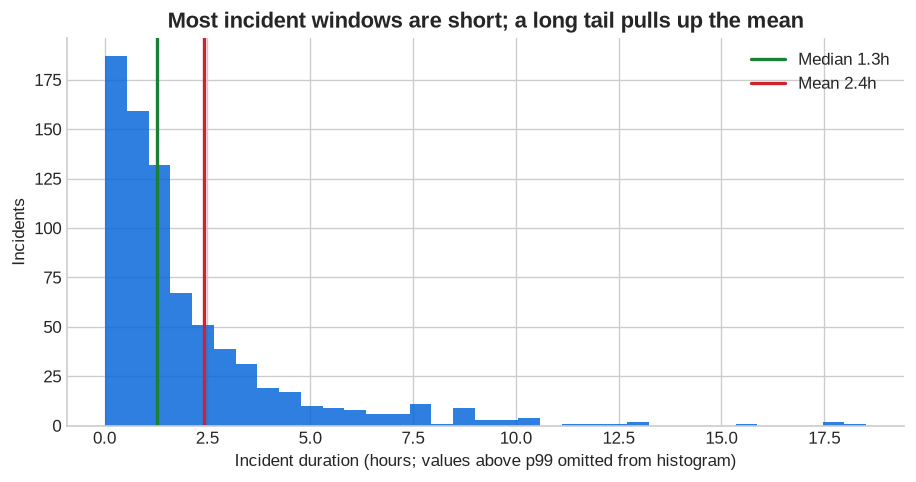

In [6]:
q = incidents["duration_hours"].quantile([0.5, 0.75, 0.90, 0.95, 0.99])
duration_summary = pd.Series({
    "Median": q.loc[0.50], "Mean": incidents["duration_hours"].mean(),
    "p75": q.loc[0.75], "p90": q.loc[0.90], "p95": q.loc[0.95],
    "p99": q.loc[0.99], "Maximum": incidents["duration_hours"].max(),
}, name="hours").to_frame()
display(duration_summary.style.format("{:.2f}"))

longest = incidents.nlargest(10, "duration_hours")[["start", "end", "duration_hours", "impact", "title"]]
display(longest.style.format({"duration_hours": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(9, 4.2))
upper = incidents["duration_hours"].quantile(0.99)
ax.hist(incidents.loc[incidents["duration_hours"] <= upper, "duration_hours"], bins=35, color=COLORS["blue"], alpha=.85)
ax.axvline(q.loc[.5], color=COLORS["green"], lw=2, label=f"Median {q.loc[.5]:.1f}h")
ax.axvline(incidents["duration_hours"].mean(), color=COLORS["red"], lw=2, label=f"Mean {incidents['duration_hours'].mean():.1f}h")
ax.set(title="Most incident windows are short; a long tail pulls up the mean", xlabel="Incident duration (hours; values above p99 omitted from histogram)", ylabel="Incidents")
ax.legend()
plt.show()

In [7]:
tail_share = incidents.nlargest(max(1, int(np.ceil(len(incidents) * .01))), "duration_hours")["duration_hours"].sum() / incidents["duration_hours"].sum()
display(Markdown(
    f"**Interpretation.** The median incident lasts **{q.loc[.5]:.2f} hours**, versus a mean of "
    f"**{incidents['duration_hours'].mean():.2f} hours**. The longest 1% of incidents account for "
    f"**{tail_share:.1%} of summed incident-hours**, so the mean is materially influenced by a small tail."
))

**Interpretation.** The median incident lasts **1.27 hours**, versus a mean of **2.41 hours**. The longest 1% of incidents account for **15.4% of summed incident-hours**, so the mean is materially influenced by a small tail.

## 4. How much observed time had at least one reported incident active?

Incident windows overlap. The defensible exposure measure merges exact half-open timestamp intervals first; summing raw durations would count concurrent windows more than once.

The observation window begins at the **earliest valid raw source timestamp**, including records later classified as maintenance. This represents archive availability independently of the reliability-cleaning decision. Download time is the right boundary.

In [8]:
intervals = list(incidents[["start", "end"]].itertuples(index=False, name=None))
merged = merge_intervals(intervals)

prior_observation_start = incidents["start"].min()  # prior definition, retained only to quantify the correction
observation_start = source_coverage_start
observation_end = downloaded_at

naive_hours = incidents["duration_hours"].sum()
unique_hours = interval_hours(clip_intervals(merged, observation_start, observation_end))
observed_hours = (observation_end - observation_start).total_seconds() / 3600
overlap_hours = naive_hours - unique_hours

prior_observed_hours = (observation_end - prior_observation_start).total_seconds() / 3600
prior_active_pct = unique_hours / prior_observed_hours
corrected_active_pct = unique_hours / observed_hours
headline_exposure_change_pp = (corrected_active_pct - prior_active_pct) * 100

exposure_summary = pd.Series({
    "Archive coverage starts": observation_start,
    "First cleaned unplanned incident starts": prior_observation_start,
    "Naive sum of incident durations (hours)": naive_hours,
    "Unique time with ≥1 active incident (hours)": unique_hours,
    "Overlap removed (hours)": overlap_hours,
    "Total observed time (hours)": observed_hours,
    "Share of observed time with ≥1 active incident": corrected_active_pct,
    "Prior-definition active share": prior_active_pct,
    "Correction (percentage points)": headline_exposure_change_pp,
})
display(exposure_summary.to_frame("value"))

,value
Archive coverage starts,2022-03-24 19:11:00+00:00
First cleaned unplanned incident starts,2022-03-26 01:43:00+00:00
Naive sum of incident durations (hours),1904.083333
Unique time with ≥1 active incident (hours),1816.65
Overlap removed (hours),87.433333
Total observed time (hours),38992.911456
Share of observed time with ≥1 active incident,0.046589
Prior-definition active share,0.046626
Correction (percentage points),-0.003651


In [9]:
display(Markdown(
    f"**Interpretation.** At least one reported incident was active for **{fmt_hours(unique_hours)}**, or "
    f"**{corrected_active_pct:.3%} of the observed interval**. Simply summing windows gives "
    f"{fmt_hours(naive_hours)} and overstates exposure by **{overlap_hours / naive_hours:.1%}** because overlapping incidents are double-counted. "
    f"Using raw archive coverage instead of the first surviving incident changes the headline exposure by "
    f"**{headline_exposure_change_pp:+.3f} percentage points** ({prior_active_pct:.3%} → {corrected_active_pct:.3%}); "
    f"this is **{'not material' if abs(headline_exposure_change_pp) < 0.1 else 'material'}** at article-level precision."
))

**Interpretation.** At least one reported incident was active for **75.7 days**, or **4.659% of the observed interval**. Simply summing windows gives 79.3 days and overstates exposure by **4.6%** because overlapping incidents are double-counted. Using raw archive coverage instead of the first surviving incident changes the headline exposure by **-0.004 percentage points** (4.663% → 4.659%); this is **not material** at article-level precision.

## 5. When did incident activity form visible waves?

Each square below is a UTC calendar day. Color encodes exact unique active hours after overlapping windows are merged and split at midnight.

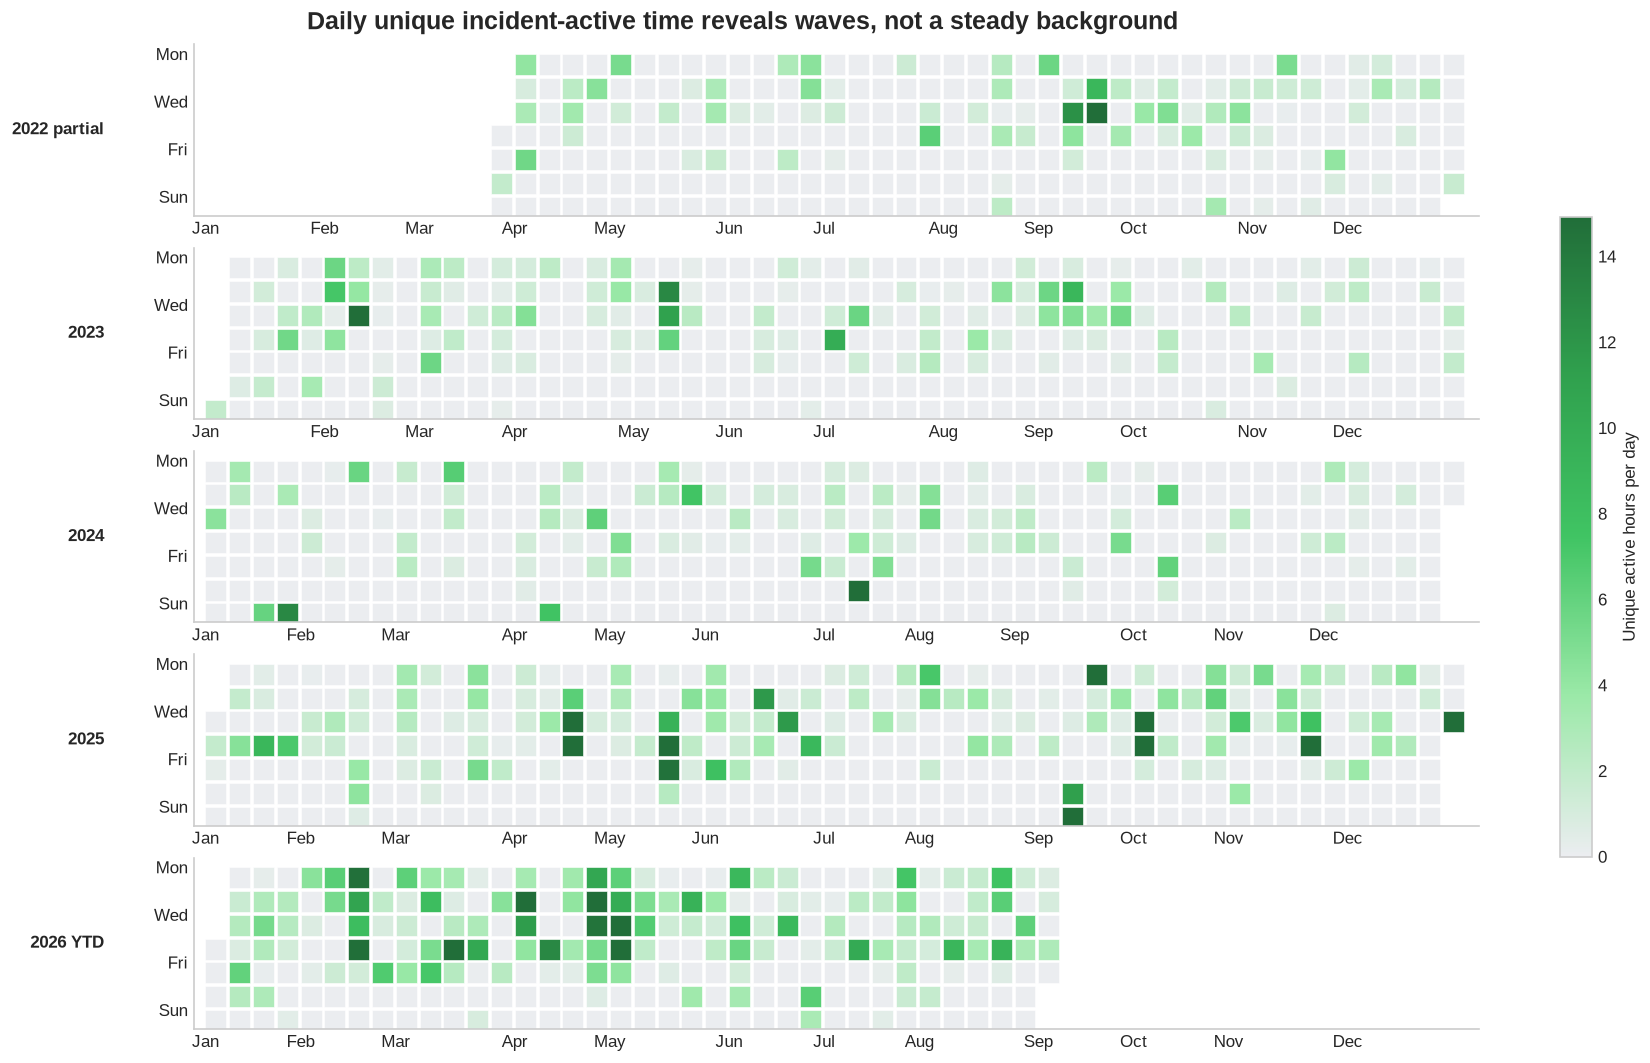

In [10]:
daily_index = pd.date_range(observation_start.floor("D"), observation_end.floor("D"), freq="D", tz="UTC")
daily = pd.DataFrame(index=daily_index)
daily["incident_starts"] = incidents.groupby("date").size().reindex(daily.index, fill_value=0)
daily["active_hours"] = allocate_to_bins(merged, "D", observation_start, observation_end).reindex(daily.index, fill_value=0)
daily["observed_hours"] = 24.0
daily.loc[daily.index[0], "observed_hours"] = (daily.index[0] + pd.Timedelta(days=1) - observation_start).total_seconds() / 3600
daily.loc[daily.index[-1], "observed_hours"] = (observation_end - daily.index[-1]).total_seconds() / 3600
daily["active_pct"] = daily["active_hours"].div(daily["observed_hours"]).clip(0, 1)

years = list(range(daily.index.year.min(), daily.index.year.max() + 1))
fig, axes = plt.subplots(len(years), 1, figsize=(15, 1.75 * len(years)), constrained_layout=True)
axes = np.atleast_1d(axes)
cmap = mcolors.LinearSegmentedColormap.from_list("github", ["#ebedf0", "#9be9a8", "#40c463", "#30a14e", "#216e39"])
norm = mcolors.Normalize(0, max(8, daily["active_hours"].quantile(.99)))
for ax, year in zip(axes, years):
    year_days = daily[daily.index.year == year]
    jan1 = pd.Timestamp(f"{year}-01-01", tz="UTC")
    week0 = jan1 - pd.Timedelta(days=jan1.weekday())
    for date, row in year_days.iterrows():
        x = (date - week0).days // 7
        y = date.weekday()
        ax.add_patch(Rectangle((x, y), .88, .88, facecolor=cmap(norm(row["active_hours"])), edgecolor="white", lw=.35))
    ax.set_xlim(-.5, 53.5); ax.set_ylim(6.8, -.4); ax.set_aspect("equal")
    ax.set_yticks(range(7), ["Mon", "", "Wed", "", "Fri", "", "Sun"])
    month_pos, month_labels = [], []
    for month in range(1, 13):
        d = pd.Timestamp(year=year, month=month, day=1, tz="UTC")
        month_pos.append((d - week0).days // 7); month_labels.append(d.strftime("%b"))
    ax.set_xticks(month_pos, month_labels)
    ax.grid(False); ax.set_ylabel(label_year(year), rotation=0, ha="right", va="center", labelpad=30, weight="bold")
fig.suptitle("Daily unique incident-active time reveals waves, not a steady background", fontsize=15, weight="bold")
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=axes, location="right", shrink=.65, label="Unique active hours per day")
plt.show()

# The same exact daily series is also available as an interactive Mercury calendar.
calendar_for_mercury = daily.reset_index(names="date")[["date", "active_hours"]]
mr.ActivityCalendar(
    calendar_for_mercury, date="date", value="active_hours",
    title="Unique incident-active hours by UTC day", unit="hours", color="green",
    start_date=observation_start, end_date=observation_end,
)

In [11]:
worst_days_preview = daily.nlargest(5, "active_hours")[["active_hours", "incident_starts"]]
display(worst_days_preview.style.format({"active_hours": "{:.2f}"}))
display(Markdown(
    f"**Interpretation.** The calendar shows concentrated waves separated by quieter stretches. The worst UTC day was "
    f"**{worst_days_preview.index[0]:%Y-%m-%d}**, with at least one incident active for "
    f"**{worst_days_preview.iloc[0]['active_hours']:.2f} hours**. A dark day denotes reported incident exposure, not necessarily a platform-wide outage."
))

,active_hours,incident_starts
2025-04-16 00:00:00+00:00,24.00,1
2025-09-14 00:00:00+00:00,24.00,0
2025-11-20 00:00:00+00:00,24.00,1
2026-04-29 00:00:00+00:00,24.00,0
2026-04-30 00:00:00+00:00,24.00,0


**Interpretation.** The calendar shows concentrated waves separated by quieter stretches. The worst UTC day was **2025-04-16**, with at least one incident active for **24.00 hours**. A dark day denotes reported incident exposure, not necessarily a platform-wide outage.

## 6. Is reliability exposure changing by year?

Annual metrics use exact observed-time denominators. 2022 starts on the first record; 2026 ends at download time. “Incidents per month” divides by equivalent observed calendar months, so partial years remain comparable.

,label,incidents,observed_months,incidents_per_month,unique_active_hours,active_pct,median_hours,p90_hours,p95_hours,max_hours,median_start_gap_hours,coverage
year,,,,,,,,,,,,
2022,2022 partial,101,9.23,10.9,204.3,3.02%,1.23,4.37,5.47,26.13,37.3,2022-03-24 to 2023-01-01
2023,2023,164,12.00,13.7,266.0,3.04%,0.87,3.77,5.68,19.58,27.1,2023-01-01 to 2024-01-01
2024,2024,120,12.00,10.0,222.2,2.53%,1.06,5.25,6.54,19.15,39.2,2024-01-01 to 2025-01-01
2025,2025,188,12.00,15.7,543.6,6.21%,1.41,6.12,8.93,56.28,25.8,2025-01-01 to 2026-01-01
2026,2026 YTD,216,8.12,26.6,580.5,9.81%,1.48,6.62,9.18,61.97,17.1,2026-01-01 to 2026-09-04


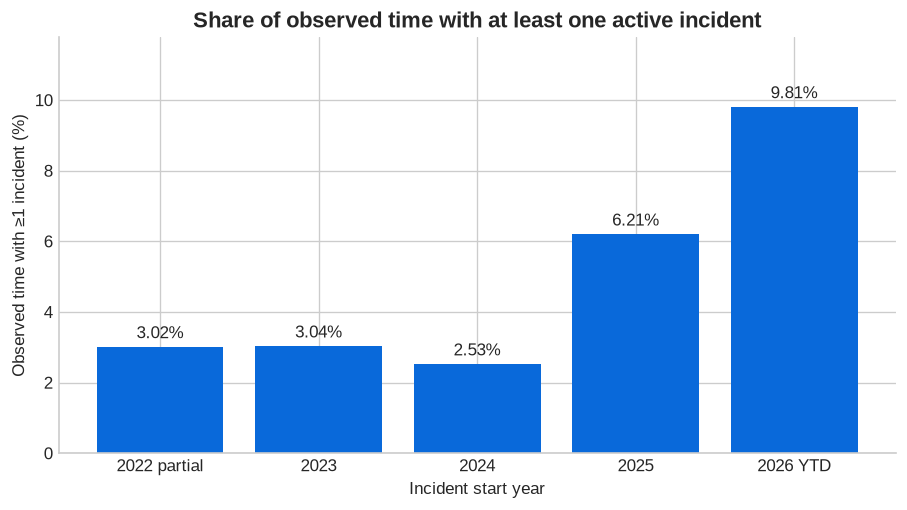

In [12]:
year_rows = []
for year in range(int(incidents.year.min()), int(downloaded_at.year) + 1):
    left = max(observation_start, pd.Timestamp(f"{year}-01-01", tz="UTC"))
    right = min(observation_end, pd.Timestamp(f"{year + 1}-01-01", tz="UTC"))
    if right <= left:
        continue
    yi = incidents[incidents.year == year]
    active_h = interval_hours(clip_intervals(merged, left, right))
    observed_h = (right - left).total_seconds() / 3600
    month_equiv = 0.0
    for period in pd.period_range(left.tz_localize(None).to_period("M"), (right - pd.Timedelta(microseconds=1)).tz_localize(None).to_period("M"), freq="M"):
        ms = pd.Timestamp(period.start_time, tz="UTC"); me = pd.Timestamp(period.end_time + pd.Timedelta(nanoseconds=1), tz="UTC")
        month_equiv += max((min(right, me) - max(left, ms)).total_seconds(), 0) / (me - ms).total_seconds()
    gaps = yi["start"].sort_values().diff().dt.total_seconds().div(3600)
    year_rows.append({
        "year": year, "label": label_year(year), "incidents": len(yi), "observed_months": month_equiv,
        "incidents_per_month": len(yi) / month_equiv, "unique_active_hours": active_h,
        "active_pct": active_h / observed_h, "median_hours": yi.duration_hours.median(),
        "p90_hours": yi.duration_hours.quantile(.90), "p95_hours": yi.duration_hours.quantile(.95),
        "max_hours": yi.duration_hours.max(), "median_start_gap_hours": gaps.median(),
        "coverage": f"{left:%Y-%m-%d} to {right:%Y-%m-%d}",
    })
yearly = pd.DataFrame(year_rows).set_index("year")
display(yearly[["label", "incidents", "observed_months", "incidents_per_month", "unique_active_hours", "active_pct", "median_hours", "p90_hours", "p95_hours", "max_hours", "median_start_gap_hours", "coverage"]].style.format({
    "observed_months": "{:.2f}", "incidents_per_month": "{:.1f}", "unique_active_hours": "{:.1f}", "active_pct": "{:.2%}",
    "median_hours": "{:.2f}", "p90_hours": "{:.2f}", "p95_hours": "{:.2f}", "max_hours": "{:.2f}", "median_start_gap_hours": "{:.1f}",
}))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(yearly["label"], yearly["active_pct"] * 100, color=COLORS["blue"])
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.set(title="Share of observed time with at least one active incident", xlabel="Incident start year", ylabel="Observed time with ≥1 incident (%)")
ax.set_ylim(0, yearly.active_pct.max() * 120)
plt.show()

In [13]:
lo, hi = yearly.iloc[0], yearly.iloc[-1]
display(Markdown(
    f"**Interpretation.** The observed incident-active share is **{lo.active_pct:.2%}** in {lo.label} and "
    f"**{hi.active_pct:.2%}** in {hi.label}. The incident-start rate moves from **{lo.incidents_per_month:.1f}** to "
    f"**{hi.incidents_per_month:.1f} per observed month**. These are reporting-window measures; changes can reflect both reliability and status-reporting scope."
))

**Interpretation.** The observed incident-active share is **3.02%** in 2022 partial and **9.81%** in 2026 YTD. The incident-start rate moves from **10.9** to **26.6 per observed month**. These are reporting-window measures; changes can reflect both reliability and status-reporting scope.

## 7. Has the typical incident changed, or mainly the long tail?

Median, p90, and p95 durations separate the typical experience from rare, extended incidents. The incomplete 2026 sample is labeled YTD.

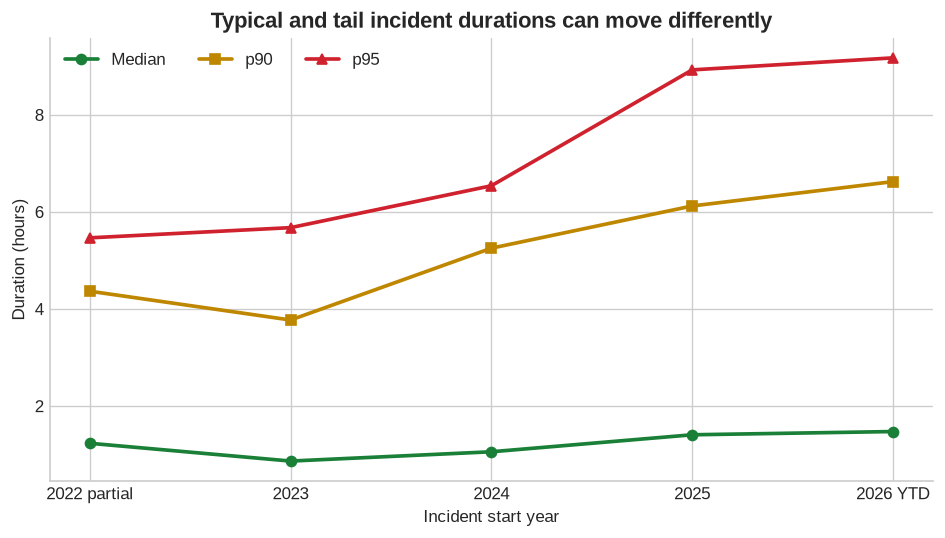

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for col, name, color, marker in [
    ("median_hours", "Median", COLORS["green"], "o"),
    ("p90_hours", "p90", COLORS["orange"], "s"),
    ("p95_hours", "p95", COLORS["red"], "^"),
]:
    ax.plot(yearly["label"], yearly[col], marker=marker, lw=2.2, label=name, color=color)
ax.set(title="Typical and tail incident durations can move differently", xlabel="Incident start year", ylabel="Duration (hours)")
ax.legend(ncol=3)
plt.show()

In [15]:
med_change = yearly.iloc[-1].median_hours / yearly.iloc[0].median_hours - 1
p95_change = yearly.iloc[-1].p95_hours / yearly.iloc[0].p95_hours - 1
display(Markdown(
    f"**Interpretation.** From {yearly.iloc[0].label} to {yearly.iloc[-1].label}, the median changed "
    f"from **{yearly.iloc[0].median_hours:.2f}h** to **{yearly.iloc[-1].median_hours:.2f}h** ({med_change:+.0%}), while p95 changed "
    f"from **{yearly.iloc[0].p95_hours:.2f}h** to **{yearly.iloc[-1].p95_hours:.2f}h** ({p95_change:+.0%}). "
    "With only a few annual cohorts and a partial final year, this is descriptive rather than evidence of a structural trend."
))

**Interpretation.** From 2022 partial to 2026 YTD, the median changed from **1.23h** to **1.48h** (+20%), while p95 changed from **5.47h** to **9.18h** (+68%). With only a few annual cohorts and a partial final year, this is descriptive rather than evidence of a structural trend.

## 8. Are incidents arriving closer together?

The gap is measured from one incident start to the next, independent of when the earlier incident ended. Short-gap shares make “bursty” periods visible without assuming statistical dependence.

,median,p25,p75,within_6h,within_24h,within_7d
2022 partial,37.3,14.2,107.1,11.9%,37.6%,92.1%
2023,27.2,11.1,71.2,16.5%,46.3%,94.5%
2024,39.4,12.9,107.8,17.5%,40.8%,90.0%
2025,25.9,8.0,74.6,19.7%,47.3%,97.3%
2026 YTD,17.2,4.5,39.5,31.0%,62.5%,100.0%


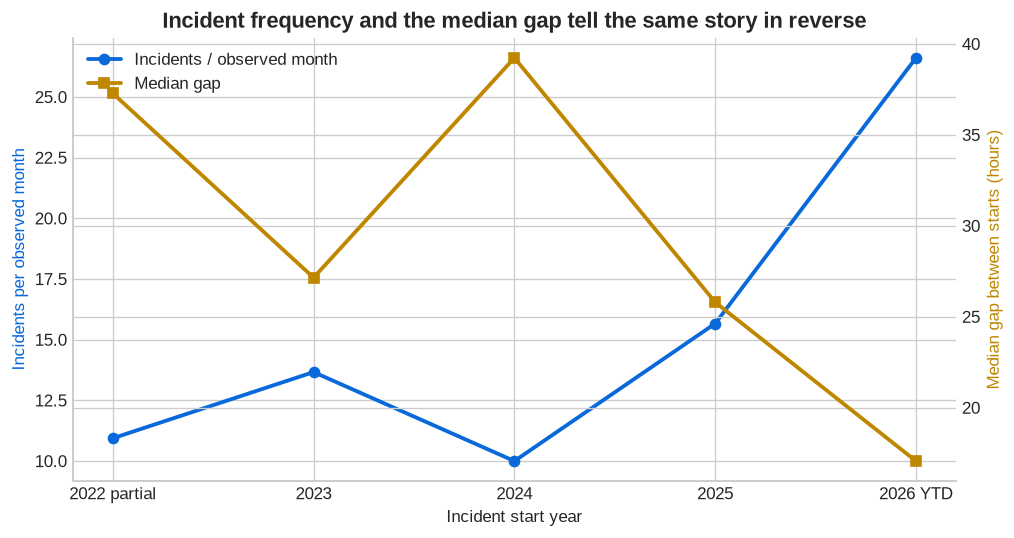

In [16]:
incidents["start_gap_hours"] = incidents["start"].diff().dt.total_seconds() / 3600
gap_yearly = incidents.groupby("year")["start_gap_hours"].agg(
    median="median", p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75),
    within_6h=lambda s: s.le(6).mean(), within_24h=lambda s: s.le(24).mean(), within_7d=lambda s: s.le(168).mean(),
)
gap_yearly.index = [label_year(y) for y in gap_yearly.index]
display(gap_yearly.style.format({"median": "{:.1f}", "p25": "{:.1f}", "p75": "{:.1f}", "within_6h": "{:.1%}", "within_24h": "{:.1%}", "within_7d": "{:.1%}"}))

fig, ax1 = plt.subplots(figsize=(9.5, 4.8))
x = np.arange(len(yearly))
ax1.plot(x, yearly["incidents_per_month"], marker="o", lw=2.3, color=COLORS["blue"], label="Incidents / observed month")
ax1.set_xticks(x, yearly["label"]); ax1.set_ylabel("Incidents per observed month", color=COLORS["blue"]); ax1.set_xlabel("Incident start year")
ax2 = ax1.twinx()
ax2.plot(x, yearly["median_start_gap_hours"], marker="s", lw=2.3, color=COLORS["orange"], label="Median gap")
ax2.set_ylabel("Median gap between starts (hours)", color=COLORS["orange"])
ax1.set_title("Incident frequency and the median gap tell the same story in reverse")
lines = ax1.lines + ax2.lines; ax1.legend(lines, [l.get_label() for l in lines], loc="best")
plt.show()

In [17]:
display(Markdown(
    f"**Interpretation.** The median gap is **{yearly.iloc[0].median_start_gap_hours:.1f}h** in {yearly.iloc[0].label} and "
    f"**{yearly.iloc[-1].median_start_gap_hours:.1f}h** in {yearly.iloc[-1].label}. In the latest cohort, "
    f"**{gap_yearly.iloc[-1].within_24h:.1%}** of starts occur within 24 hours of the preceding start. "
    "This describes temporal crowding; it does not prove incidents cause one another."
))

**Interpretation.** The median gap is **37.3h** in 2022 partial and **17.1h** in 2026 YTD. In the latest cohort, **62.5%** of starts occur within 24 hours of the preceding start. This describes temporal crowding; it does not prove incidents cause one another.

## 9. Do incident starts and incident exposure peak at the same weekly time?

The first heatmap counts when incidents **begin**. The second allocates merged active intervals across exact UTC hour bins and divides by the amount of each weekday/hour actually observed. This avoids confusing arrivals with time spent under incident conditions.

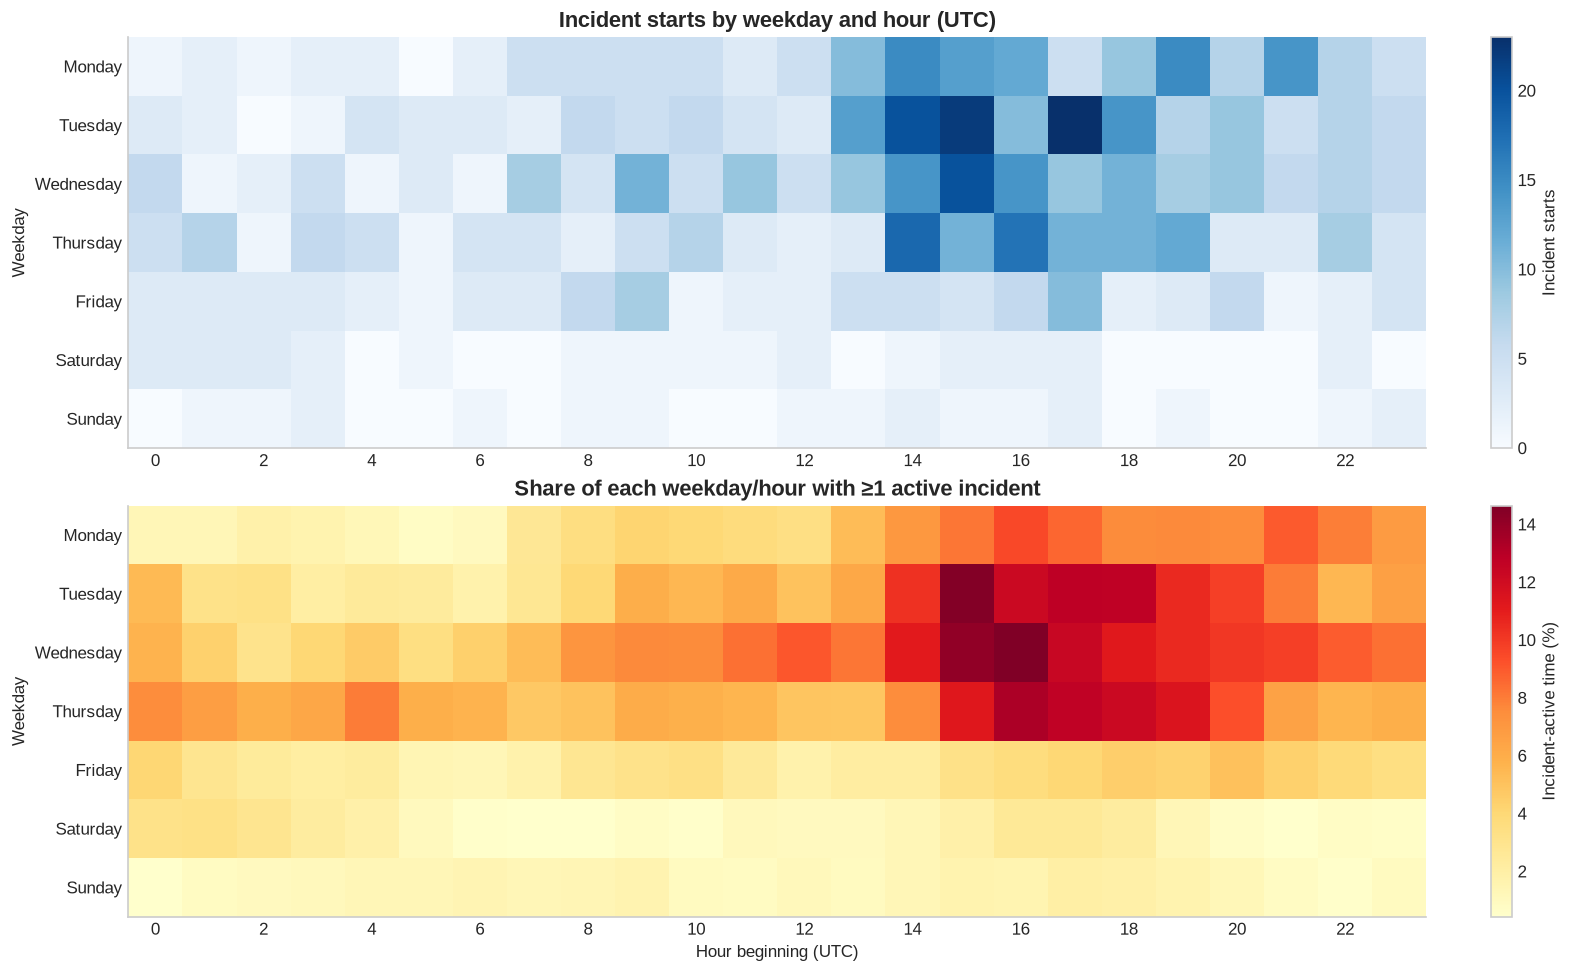

In [18]:
start_heat = pd.crosstab(incidents["weekday"], incidents["hour"]).reindex(index=WEEKDAYS, columns=range(24), fill_value=0)

hourly_active = allocate_to_bins(merged, "h", observation_start, observation_end)
hourly_observed = allocate_to_bins([(observation_start, observation_end)], "h", observation_start, observation_end)
hour_frame = pd.DataFrame({"active": hourly_active, "observed": hourly_observed}).fillna(0)
hour_frame["weekday"] = pd.Categorical(hour_frame.index.day_name(), categories=WEEKDAYS, ordered=True)
hour_frame["hour"] = hour_frame.index.hour
exposure_heat = (hour_frame.groupby(["weekday", "hour"], observed=False)["active"].sum() /
                 hour_frame.groupby(["weekday", "hour"], observed=False)["observed"].sum()).unstack().reindex(index=WEEKDAYS, columns=range(24))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
im0 = axes[0].imshow(start_heat, aspect="auto", cmap="Blues")
axes[0].set(title="Incident starts by weekday and hour (UTC)", ylabel="Weekday")
fig.colorbar(im0, ax=axes[0], label="Incident starts")
im1 = axes[1].imshow(exposure_heat * 100, aspect="auto", cmap="YlOrRd")
axes[1].set(title="Share of each weekday/hour with ≥1 active incident", xlabel="Hour beginning (UTC)", ylabel="Weekday")
fig.colorbar(im1, ax=axes[1], label="Incident-active time (%)")
for ax in axes:
    ax.set_yticks(range(7), WEEKDAYS); ax.set_xticks(range(0, 24, 2)); ax.grid(False)
plt.show()

weekday_starts = incidents["weekday"].value_counts().reindex(WEEKDAYS)
hour_starts = incidents["hour"].value_counts().sort_index()
start_peak = np.unravel_index(np.nanargmax(start_heat.values), start_heat.shape)
exposure_peak = np.unravel_index(np.nanargmax(exposure_heat.values), exposure_heat.shape)

In [19]:
display(Markdown(
    f"**Interpretation.** The busiest start cell is **{WEEKDAYS[start_peak[0]]} {start_peak[1]:02d}:00–{(start_peak[1]+1)%24:02d}:00 UTC** "
    f"with **{int(start_heat.iloc[start_peak])} starts**. The highest-exposure cell is "
    f"**{WEEKDAYS[exposure_peak[0]]} {exposure_peak[1]:02d}:00–{(exposure_peak[1]+1)%24:02d}:00 UTC**, active for "
    f"**{exposure_heat.iloc[exposure_peak]:.2%}** of observed time in that bucket. "
    f"The peaks {'differ' if start_peak != exposure_peak else 'coincide'}, confirming that start frequency and accumulated exposure answer different questions."
))

**Interpretation.** The busiest start cell is **Tuesday 17:00–18:00 UTC** with **23 starts**. The highest-exposure cell is **Wednesday 16:00–17:00 UTC**, active for **14.65%** of observed time in that bucket. The peaks differ, confirming that start frequency and accumulated exposure answer different questions.

### Which weekday has the most incident exposure?

This table aggregates the exact hourly allocation by weekday. It reports accumulated active time and the matching observed-time denominator; incident-start counts are intentionally kept separate.

,unique_active_hours,observed_hours,active_pct
weekday,,,
Monday,267.98,"5,568.00",4.813%
Tuesday,368.82,"5,568.00",6.624%
Wednesday,449.73,"5,568.00",8.077%
Thursday,415.05,"5,572.82",7.448%
Friday,168.30,"5,580.09",3.016%
Saturday,79.70,"5,568.00",1.431%
Sunday,67.07,"5,568.00",1.205%


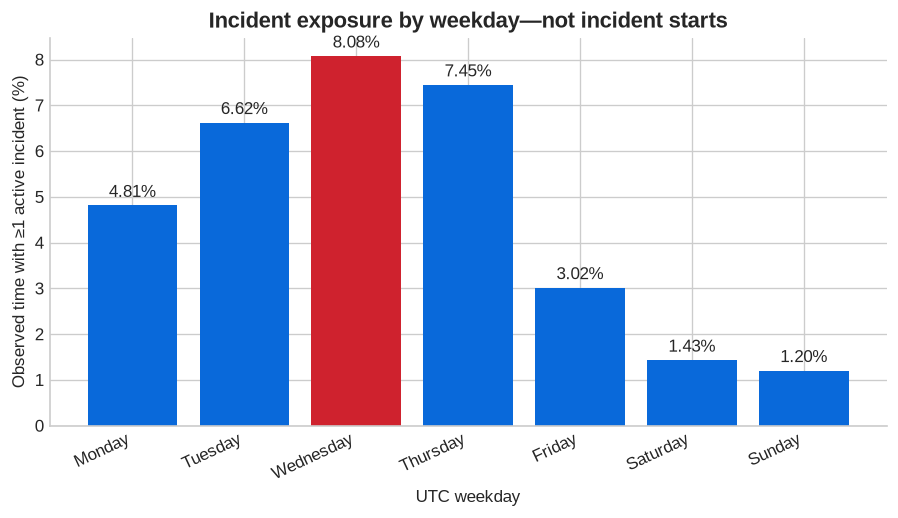

In [20]:
weekday_exposure = hour_frame.groupby("weekday", observed=False)[["active", "observed"]].sum().reindex(WEEKDAYS)
weekday_exposure.columns = ["unique_active_hours", "observed_hours"]
weekday_exposure["active_pct"] = weekday_exposure["unique_active_hours"] / weekday_exposure["observed_hours"]
display(weekday_exposure.style.format({
    "unique_active_hours": "{:.2f}", "observed_hours": "{:,.2f}", "active_pct": "{:.3%}"
}))

fig, ax = plt.subplots(figsize=(9, 4.2))
weekday_colors = [COLORS["red"] if d == weekday_exposure.active_pct.idxmax() else COLORS["blue"] for d in WEEKDAYS]
bars = ax.bar(WEEKDAYS, weekday_exposure.active_pct * 100, color=weekday_colors)
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.set(title="Incident exposure by weekday—not incident starts", xlabel="UTC weekday", ylabel="Observed time with ≥1 active incident (%)")
plt.xticks(rotation=25, ha="right")
plt.show()

highest_exposure_weekday = weekday_exposure.active_pct.idxmax()
lowest_exposure_weekday = weekday_exposure.active_pct.idxmin()
weekday_exposure_ratio = (weekday_exposure.loc[highest_exposure_weekday, "active_pct"] /
                          weekday_exposure.loc[lowest_exposure_weekday, "active_pct"])

In [21]:
display(Markdown(
    f"**Interpretation.** **{highest_exposure_weekday}** has the highest exposure "
    f"(**{weekday_exposure.loc[highest_exposure_weekday, 'active_pct']:.3%}**); "
    f"**{lowest_exposure_weekday}** has the lowest "
    f"(**{weekday_exposure.loc[lowest_exposure_weekday, 'active_pct']:.3%}**). "
    f"The high-to-low ratio is **{weekday_exposure_ratio:.2f}×**. These are active-time shares, not start counts."
))

**Interpretation.** **Wednesday** has the highest exposure (**8.077%**); **Sunday** has the lowest (**1.205%**). The high-to-low ratio is **6.71×**. These are active-time shares, not start counts.

### Which UTC hours accumulate the most exposure?

Hourly exposure aggregates the exact allocation across all weekdays. A side-by-side start-count chart makes the arrival-versus-duration distinction explicit.

,unique_active_hours,observed_hours,active_pct,incident_starts
hour,,,,
0,64.12,"1,625.00",3.946%,21
1,52.23,"1,625.00",3.214%,19
2,47.18,"1,625.00",2.904%,11
3,45.10,"1,625.00",2.775%,21
4,50.30,"1,625.00",3.095%,14
5,37.52,"1,625.00",2.309%,9
6,37.07,"1,625.00",2.281%,14
7,43.93,"1,625.00",2.704%,22
8,56.23,"1,625.00",3.461%,25


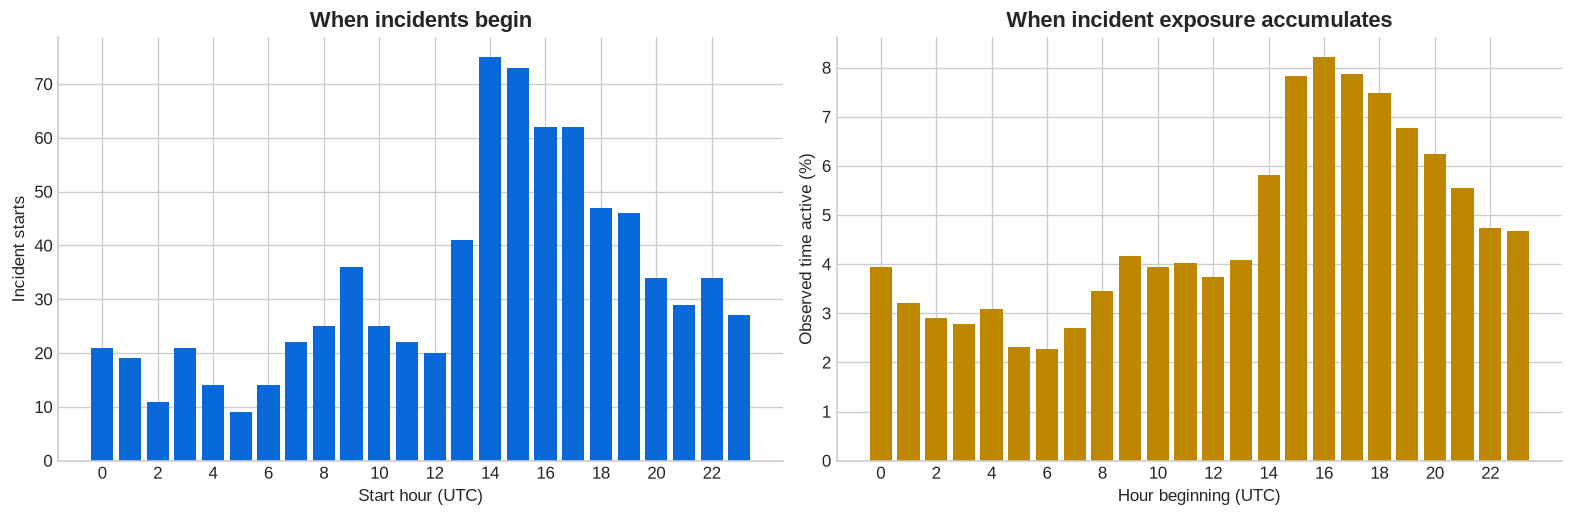

In [22]:
hour_exposure = hour_frame.groupby("hour")[["active", "observed"]].sum().reindex(range(24))
hour_exposure.columns = ["unique_active_hours", "observed_hours"]
hour_exposure["active_pct"] = hour_exposure["unique_active_hours"] / hour_exposure["observed_hours"]
hour_exposure["incident_starts"] = hour_starts.reindex(range(24), fill_value=0).astype(int)
display(hour_exposure.style.format({
    "unique_active_hours": "{:.2f}", "observed_hours": "{:,.2f}", "active_pct": "{:.3%}"
}))

peak_exposure_hour = int(hour_exposure.active_pct.idxmax())
lowest_exposure_hour = int(hour_exposure.active_pct.idxmin())
peak_start_hour = int(hour_exposure.incident_starts.idxmax())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
axes[0].bar(range(24), hour_exposure.incident_starts, color=COLORS["blue"])
axes[0].set(title="When incidents begin", xlabel="Start hour (UTC)", ylabel="Incident starts", xticks=range(0, 24, 2))
axes[1].bar(range(24), hour_exposure.active_pct * 100, color=COLORS["orange"])
axes[1].set(title="When incident exposure accumulates", xlabel="Hour beginning (UTC)", ylabel="Observed time active (%)", xticks=range(0, 24, 2))
plt.show()

In [23]:
display(Markdown(
    f"**Interpretation.** Exposure peaks at **{peak_exposure_hour:02d}:00–{(peak_exposure_hour + 1) % 24:02d}:00 UTC** "
    f"(**{hour_exposure.loc[peak_exposure_hour, 'active_pct']:.3%}**) and is lowest at "
    f"**{lowest_exposure_hour:02d}:00–{(lowest_exposure_hour + 1) % 24:02d}:00 UTC** "
    f"(**{hour_exposure.loc[lowest_exposure_hour, 'active_pct']:.3%}**). Starts peak at "
    f"**{peak_start_hour:02d}:00 UTC** ({hour_exposure.loc[peak_start_hour, 'incident_starts']} starts). "
    f"The peak hours {'differ' if peak_start_hour != peak_exposure_hour else 'coincide'}: start counts measure arrivals; exposure also reflects duration."
))

**Interpretation.** Exposure peaks at **16:00–17:00 UTC** (**8.214%**) and is lowest at **06:00–07:00 UTC** (**2.281%**). Starts peak at **14:00 UTC** (75 starts). The peak hours differ: start counts measure arrivals; exposure also reflects duration.

## 10. Is there calendar-month seasonality?

Counts are divided by the fractional number of each calendar month observed. This matters because coverage begins in March 2022 and ends during 2026 YTD.

,incidents,observed_months,incidents_per_observed_month
Jan,61,4.00,15.2
Feb,78,4.00,19.5
Mar,79,4.23,18.7
Apr,80,5.00,16.0
May,66,5.00,13.2
Jun,73,5.00,14.6
Jul,75,5.00,15.0
Aug,76,5.00,15.2
Sep,63,4.12,15.3
Oct,47,4.00,11.8


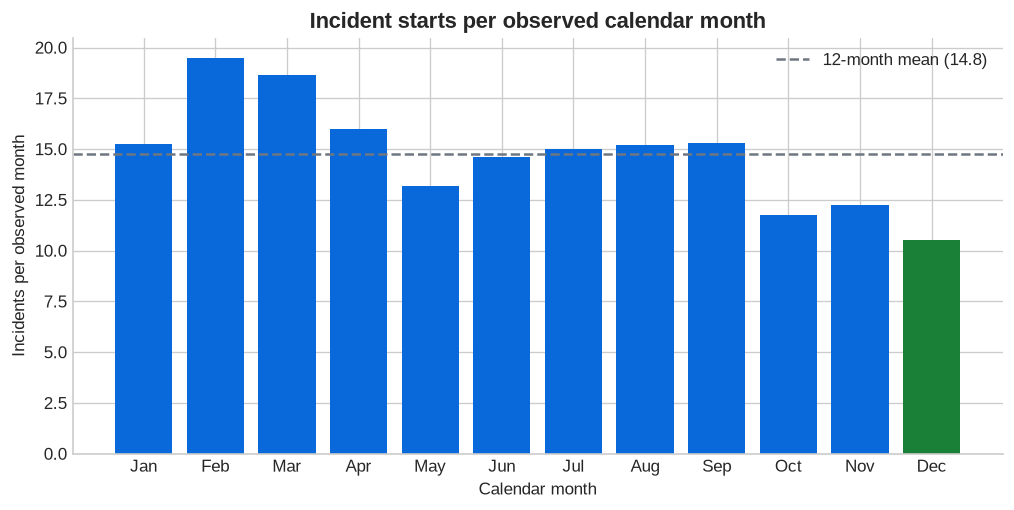

In [24]:
month_exposure = Counter()
cursor = observation_start.floor("D").replace(day=1)
while cursor < observation_end:
    nxt = cursor + pd.offsets.MonthBegin(1)
    overlap = max((min(nxt, observation_end) - max(cursor, observation_start)).total_seconds(), 0)
    month_exposure[cursor.month] += overlap / (nxt - cursor).total_seconds()
    cursor = nxt

month_counts = incidents["month"].value_counts().reindex(range(1, 13), fill_value=0)
month_rate = pd.Series({m: month_counts.loc[m] / month_exposure[m] for m in range(1, 13)})
monthly = pd.DataFrame({"incidents": month_counts, "observed_months": pd.Series(month_exposure), "incidents_per_observed_month": month_rate})
monthly.index = MONTHS
display(monthly.style.format({"observed_months": "{:.2f}", "incidents_per_observed_month": "{:.1f}"}))

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(MONTHS, month_rate, color=[COLORS["green"] if v == month_rate.min() else COLORS["blue"] for v in month_rate])
ax.axhline(month_rate.mean(), color=COLORS["gray"], ls="--", label=f"12-month mean ({month_rate.mean():.1f})")
ax.set(title="Incident starts per observed calendar month", xlabel="Calendar month", ylabel="Incidents per observed month")
ax.legend()
plt.show()

In [25]:
quiet_month = MONTHS[int(month_rate.values.argmin())]
busy_month = MONTHS[int(month_rate.values.argmax())]
dec_vs_avg = month_rate.loc[12] / month_rate.mean() - 1
display(Markdown(
    f"**Interpretation.** **{busy_month}** has the highest normalized rate ({month_rate.max():.1f} incidents per observed month); "
    f"**{quiet_month}** has the lowest ({month_rate.min():.1f}). December is **{abs(dec_vs_avg):.0%} "
    f"{'below' if dec_vs_avg < 0 else 'above'}** the 12-month average. With fewer than five complete annual cycles, this is weak seasonality evidence; explanations such as change freezes remain hypotheses."
))

**Interpretation.** **Feb** has the highest normalized rate (19.5 incidents per observed month); **Dec** has the lowest (10.5). December is **29% below** the 12-month average. With fewer than five complete annual cycles, this is weak seasonality evidence; explanations such as change freezes remain hypotheses.

## 11. Which services appear, and has the mix changed?

For this section only, the notebook downloads `incidents.jsonl` and joins it to the cleaned CSV by incident ID. Its `components` list is richer than title-only parsing. The source distinguishes model-inferred assignments (`components_source == "gliner2"`); these are retained but disclosed. Incidents may have multiple components, so component shares sum to more than 100%.

,incidents,share
component_attribution,,
Source-extracted,570,72.2%
Model-inferred,77,9.8%
Unattributed,142,18.0%


,year_label,component,incidents,share_of_all_incidents,median_duration_hours,p90_duration_hours
0,2022 partial,Actions,31,30.7%,1.05,2.98
1,2022 partial,Copilot,4,4.0%,1.04,1.88
2,2022 partial,Codespaces,29,28.7%,2.13,4.73
3,2022 partial,Pull Requests,12,11.9%,1.25,1.86
4,2022 partial,Issues,13,12.9%,0.97,2.98
5,2022 partial,Git Operations,9,8.9%,0.88,1.23
6,2022 partial,API Requests,6,5.9%,0.34,2.04
7,2023,Actions,61,37.2%,0.90,5.08
8,2023,Copilot,13,7.9%,0.93,2.36
9,2023,Codespaces,41,25.0%,1.07,5.45


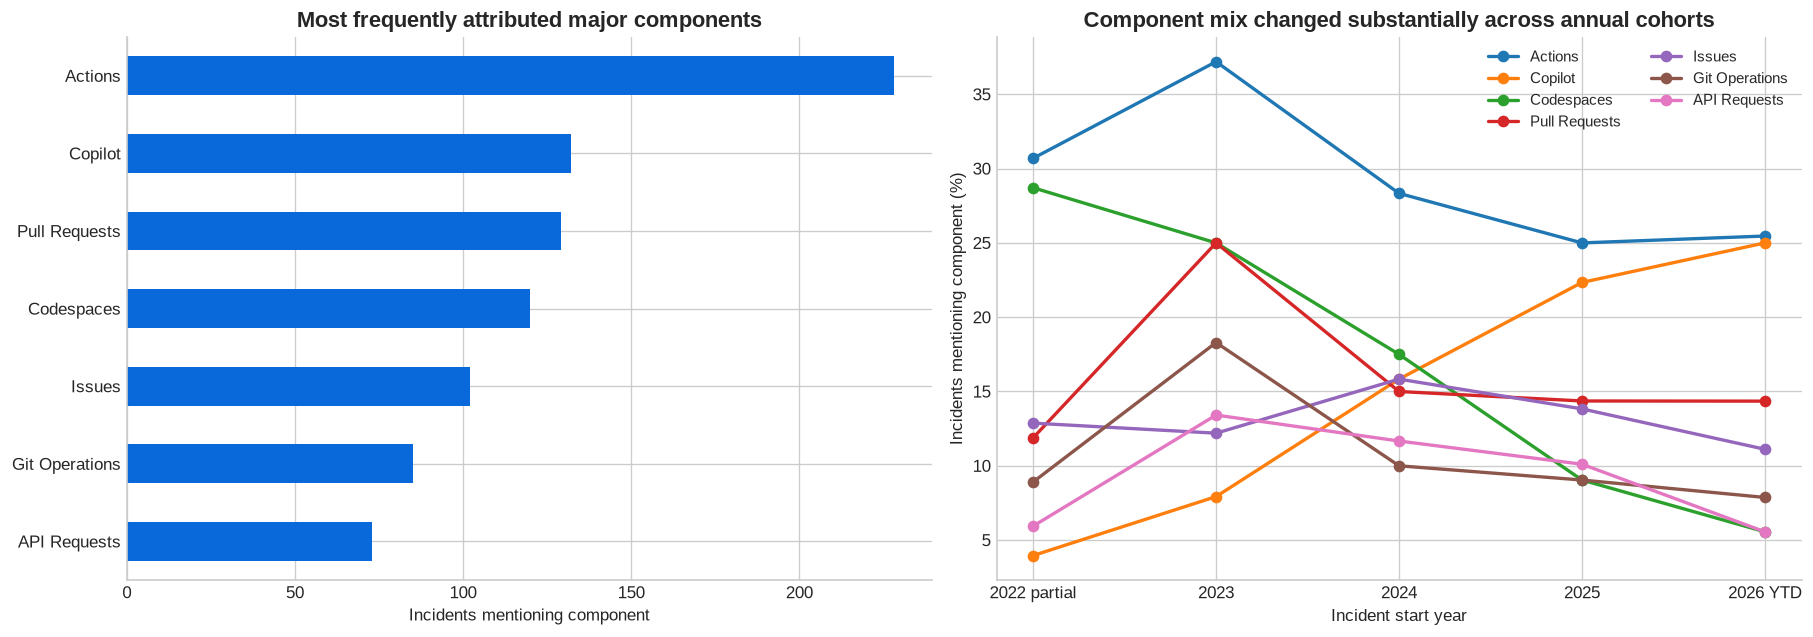

In [26]:
rich = pd.read_json(JSONL_URL, lines=True)
rich["incident_id"] = pd.to_numeric(rich["id"], errors="coerce").astype("Int64")
component_meta = rich[["incident_id", "components", "components_source", "components_confidence"]].copy()
svc = incidents.merge(component_meta, on="incident_id", how="left")
svc["components"] = svc["components"].apply(lambda x: x if isinstance(x, list) else [])
svc["component_attribution"] = np.select(
    [svc["components"].str.len().eq(0), svc["components_source"].eq("gliner2")],
    ["Unattributed", "Model-inferred"], default="Source-extracted"
)

attribution_audit = svc["component_attribution"].value_counts().rename("incidents").to_frame()
attribution_audit["share"] = attribution_audit["incidents"] / len(svc)
display(attribution_audit.reindex(["Source-extracted", "Model-inferred", "Unattributed"]).style.format({"share": "{:.1%}"}))

svc_long = (svc.explode("components").rename(columns={"components": "component"})
            .drop_duplicates(["incident_id", "components_source", "component"]))
svc_long = svc_long[svc_long["component"].notna() & svc_long["component"].ne("")]
component_counts = svc_long["component"].value_counts()

major_components = [
    "Actions", "Copilot", "Codespaces", "Pull Requests", "Issues", "Git Operations", "API Requests"
]
major_components = [c for c in major_components if c in component_counts.index]

annual_totals = incidents.groupby("year").size().rename("all_incidents")
component_yearly = (svc_long[svc_long.component.isin(major_components)]
    .groupby(["year", "component"])
    .agg(incidents=("incident_id", "nunique"),
         median_duration_hours=("duration_hours", "median"),
         p90_duration_hours=("duration_hours", lambda s: s.quantile(.90)))
    .reindex(pd.MultiIndex.from_product([annual_totals.index, major_components], names=["year", "component"]), fill_value=0)
    .reset_index())
component_yearly["share_of_all_incidents"] = component_yearly["incidents"] / component_yearly["year"].map(annual_totals)
component_yearly["year_label"] = component_yearly["year"].map(label_year)
display(component_yearly[["year_label", "component", "incidents", "share_of_all_incidents", "median_duration_hours", "p90_duration_hours"]]
        .style.format({"share_of_all_incidents": "{:.1%}", "median_duration_hours": "{:.2f}", "p90_duration_hours": "{:.2f}"}))

component_mix = component_yearly.pivot(index="year_label", columns="component", values="share_of_all_incidents")
component_mix = component_mix.reindex([label_year(y) for y in annual_totals.index])
mix_share = component_mix  # retained for downstream findings

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)
component_counts.reindex(major_components).sort_values().plot.barh(ax=axes[0], color=COLORS["blue"])
axes[0].set(title="Most frequently attributed major components", xlabel="Incidents mentioning component", ylabel="")
for component in major_components:
    axes[1].plot(component_mix.index, component_mix[component] * 100, marker="o", lw=2, label=component)
axes[1].set(title="Component mix changed substantially across annual cohorts", xlabel="Incident start year", ylabel="Incidents mentioning component (%)")
axes[1].legend(ncol=2, fontsize=9)
plt.show()

In [27]:
def service_sentence(name):
    if name not in component_mix:
        return f"{name} is not present in the attributed data."
    first, last = component_mix[name].iloc[0], component_mix[name].iloc[-1]
    delta = last - first
    if first >= .20 and last >= .20:
        direction = "remained common while rising" if delta > .02 else "remained common while declining" if delta < -.02 else "remained consistently common"
    else:
        direction = "rose" if delta > .02 else "fell" if delta < -.02 else "was broadly stable"
    return (f"{name} {direction}: {first:.1%} in {component_mix.index[0]} → "
            f"{last:.1%} in {component_mix.index[-1]} ({delta:+.1%} points).")

component_change_pp = {
    name: (component_mix[name].iloc[-1] - component_mix[name].iloc[0]) * 100
    for name in ["Actions", "Copilot", "Codespaces"] if name in component_mix
}

display(Markdown(
    f"**Interpretation.** **{svc.component_attribution.eq('Unattributed').mean():.1%}** of cleaned incidents cannot be attributed to a component; "
    f"**{svc.component_attribution.eq('Model-inferred').mean():.1%}** use the repository's model-inferred labels. "
    + " ".join(service_sentence(s) for s in ["Actions", "Copilot", "Codespaces"]) + " "
    "These are mention rates, not component-specific downtime. Incidents may mention multiple components, and reporting breadth can change the mix."
))

**Interpretation.** **18.0%** of cleaned incidents cannot be attributed to a component; **9.8%** use the repository's model-inferred labels. Actions remained common while declining: 30.7% in 2022 partial → 25.5% in 2026 YTD (-5.2% points). Copilot rose: 4.0% in 2022 partial → 25.0% in 2026 YTD (+21.0% points). Codespaces fell: 28.7% in 2022 partial → 5.6% in 2026 YTD (-23.2% points). These are mention rates, not component-specific downtime. Incidents may mention multiple components, and reporting breadth can change the mix.

## 12. Did severity change—or did the labels change?

Counts, annual shares, and durations are shown together. Severity is editorial metadata, so a label appearing abruptly is treated as a possible taxonomy/policy shift rather than automatic evidence of worsening reliability.

,incidents,share,median_duration_hours,p90_duration_hours
impact,,,,
none,18,2.3%,2.26,9.05
minor,607,76.9%,1.22,4.57
major,137,17.4%,1.28,5.61
critical,27,3.4%,2.02,8.21


,critical_incidents
year,
2022,0
2023,1
2024,0
2025,0
2026,26


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
critical_incidents_2026,0,0,0,3,8,4,6,5,0,0,0,0


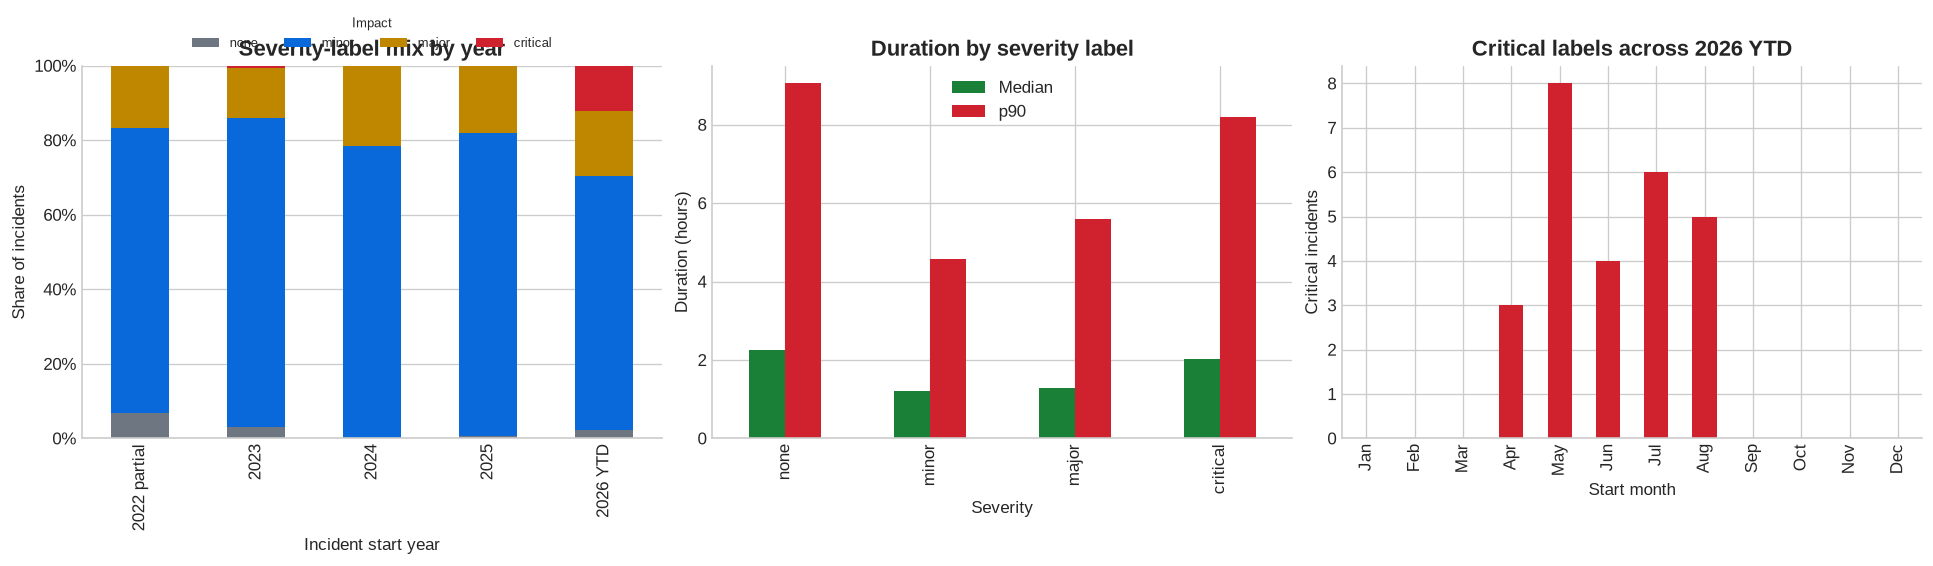

In [28]:
severity_order = [s for s in ["none", "minor", "major", "critical"] if s in incidents.impact.unique()]
severity_stats = incidents.groupby("impact")["duration_hours"].agg(
    incidents="size", median_duration_hours="median", p90_duration_hours=lambda s: s.quantile(.90)
).reindex(severity_order)
severity_stats["share"] = severity_stats["incidents"] / len(incidents)

severity_year_counts = pd.crosstab(incidents["year"], incidents["impact"]).reindex(columns=severity_order, fill_value=0)
severity_year_share = severity_year_counts.div(severity_year_counts.sum(axis=1), axis=0)
severity_year_share.index = [label_year(y) for y in severity_year_share.index]

critical = incidents[incidents.impact.eq("critical")].copy()
critical_year_counts = critical.groupby("year").size().reindex(annual_totals.index, fill_value=0)
critical_2026_monthly = critical.loc[critical.year.eq(2026)].groupby(critical.loc[critical.year.eq(2026), "start"].dt.month).size().reindex(range(1, 13), fill_value=0)
critical_2026_monthly.index = MONTHS
pre_2026_critical = critical[critical.year.lt(2026)]
first_critical_2026 = critical.loc[critical.year.eq(2026), "start"].min()

display(severity_stats[["incidents", "share", "median_duration_hours", "p90_duration_hours"]]
        .style.format({"share": "{:.1%}", "median_duration_hours": "{:.2f}", "p90_duration_hours": "{:.2f}"}))
display(critical_year_counts.rename("critical_incidents").to_frame())
display(critical_2026_monthly.rename("critical_incidents_2026").to_frame().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
severity_year_share.plot.bar(stacked=True, ax=axes[0], color=[COLORS["gray"], COLORS["blue"], COLORS["orange"], COLORS["red"]][:len(severity_order)])
axes[0].set(title="Severity-label mix by year", xlabel="Incident start year", ylabel="Share of incidents")
axes[0].legend(title="Impact", loc="lower center", bbox_to_anchor=(.5, 1.01), ncol=4, fontsize=8, title_fontsize=8)
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
severity_stats[["median_duration_hours", "p90_duration_hours"]].plot.bar(ax=axes[1], color=[COLORS["green"], COLORS["red"]])
axes[1].set(title="Duration by severity label", xlabel="Severity", ylabel="Duration (hours)")
axes[1].legend(["Median", "p90"])
critical_2026_monthly.plot.bar(ax=axes[2], color=COLORS["red"])
axes[2].set(title="Critical labels across 2026 YTD", xlabel="Start month", ylabel="Critical incidents")
plt.show()

In [29]:
critical_median_ratio = severity_stats.loc["critical", "median_duration_hours"] / severity_stats.loc["major", "median_duration_hours"]
critical_p90_ratio = severity_stats.loc["critical", "p90_duration_hours"] / severity_stats.loc["major", "p90_duration_hours"]
critical_2026_share = critical.year.eq(2026).mean()
if critical_2026_share >= .80 and max(critical_median_ratio, critical_p90_ratio) < 2:
    duration_evidence = (
        f"Critical durations are longer than major durations ({critical_median_ratio:.2f}× at the median and "
        f"{critical_p90_ratio:.2f}× at p90), but that shift is far smaller than the abrupt label-count discontinuity. "
        "The mismatch looks more consistent with a reporting/classification change than with a dramatic duration change alone"
    )
else:
    duration_evidence = ("The duration and count evidence move together enough that this dataset does not cleanly "
                         "separate a classification change from a reliability change")

display(Markdown(
    f"**Interpretation.** There are **{len(critical)} critical incidents**: "
    f"**{len(pre_2026_critical)} before 2026** and **{critical.year.eq(2026).sum()} in 2026 YTD**. "
    f"The pre-2026 record is dated **{pre_2026_critical.start.iloc[0]:%Y-%m-%d}**; the first 2026 critical record is "
    f"**{first_critical_2026:%Y-%m-%d}**. Critical duration is **{severity_stats.loc['critical', 'median_duration_hours']:.2f}h median** "
    f"and **{severity_stats.loc['critical', 'p90_duration_hours']:.2f}h p90**, versus major "
    f"(**{severity_stats.loc['major', 'median_duration_hours']:.2f}h**, **{severity_stats.loc['major', 'p90_duration_hours']:.2f}h**) and minor "
    f"(**{severity_stats.loc['minor', 'median_duration_hours']:.2f}h**, **{severity_stats.loc['minor', 'p90_duration_hours']:.2f}h**). "
    f"{duration_evidence}, but the data cannot establish the cause definitively."
))

**Interpretation.** There are **27 critical incidents**: **1 before 2026** and **26 in 2026 YTD**. The pre-2026 record is dated **2023-06-29**; the first 2026 critical record is **2026-04-22**. Critical duration is **2.02h median** and **8.21h p90**, versus major (**1.28h**, **5.61h**) and minor (**1.22h**, **4.57h**). Critical durations are longer than major durations (1.57× at the median and 1.46× at p90), but that shift is far smaller than the abrupt label-count discontinuity. The mismatch looks more consistent with a reporting/classification change than with a dramatic duration change alone, but the data cannot establish the cause definitively.

## 13. Do incidents cluster in bursts, including within the same service?

Here a “cluster” is descriptive: a short gap between starts. For component recurrence, each attributed incident-component pair is compared with the previous start for that component. Multi-component incidents therefore contribute to more than one service sequence.

,incidents,eligible_transitions,median_gap_to_next_hours,within_24h,within_7d,within_30d
component,,,,,,
Actions,228,227,127.5,20.3%,63.4%,97.8%
Copilot,132,131,132.0,18.3%,58.8%,90.8%
Pull Requests,129,128,166.7,14.1%,50.8%,90.6%
Codespaces,120,119,170.6,11.8%,48.7%,84.9%
Issues,102,101,219.9,10.9%,43.6%,85.1%
Git Operations,85,84,330.2,9.5%,34.5%,84.5%
API Requests,73,72,345.6,9.7%,31.9%,75.0%


,all incident starts,same-component transitions
Median gap (hours),24.6,179.7
Within 24 hours,49.1%,13.7%
Within 7 days,95.8%,47.6%
Within 30 days,100.0%,85.8%


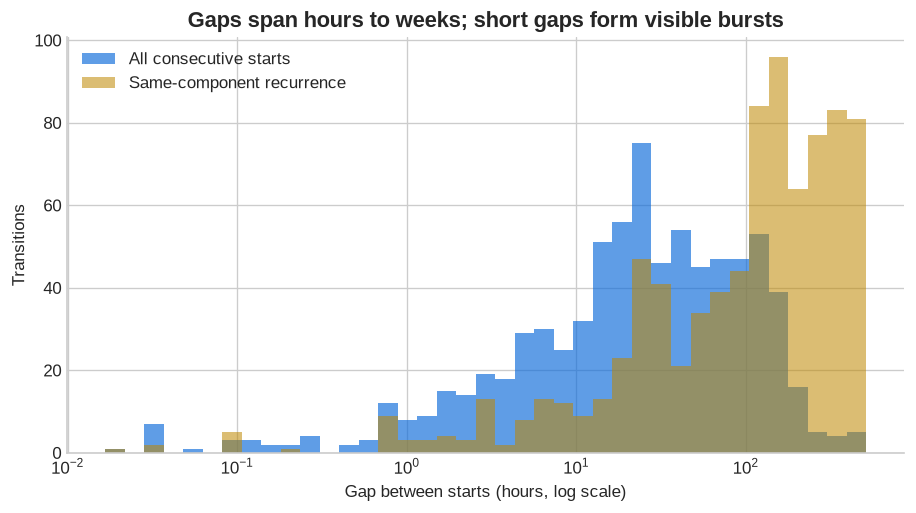

In [30]:
all_gaps = incidents["start"].sort_values().diff().dropna().dt.total_seconds() / 3600

component_sequence = (svc_long.drop_duplicates(["incident_id", "component"])
                      .sort_values(["component", "start"]).copy())
component_sequence["next_same_component_start"] = component_sequence.groupby("component")["start"].shift(-1)
component_sequence["gap_to_next_hours"] = (
    component_sequence["next_same_component_start"] - component_sequence["start"]
).dt.total_seconds() / 3600
cg = component_sequence["gap_to_next_hours"].dropna()

def recurrence_row(group):
    gaps = group["gap_to_next_hours"].dropna()
    return pd.Series({
        "incidents": group["incident_id"].nunique(),
        "eligible_transitions": len(gaps),
        "median_gap_to_next_hours": gaps.median(),
        "within_24h": gaps.le(24).mean(),
        "within_7d": gaps.le(168).mean(),
        "within_30d": gaps.le(720).mean(),
    })

component_recurrence = (component_sequence[component_sequence.component.isin(major_components)]
                        .groupby("component").apply(recurrence_row, include_groups=False)
                        .sort_values("incidents", ascending=False))
display(component_recurrence.style.format({
    "incidents": "{:.0f}", "eligible_transitions": "{:.0f}", "median_gap_to_next_hours": "{:.1f}",
    "within_24h": "{:.1%}", "within_7d": "{:.1%}", "within_30d": "{:.1%}",
}))

cluster_stats = pd.DataFrame({
    "all incident starts": [all_gaps.median(), all_gaps.le(24).mean(), all_gaps.le(168).mean(), all_gaps.le(720).mean()],
    "same-component transitions": [cg.median(), cg.le(24).mean(), cg.le(168).mean(), cg.le(720).mean()],
}, index=["Median gap (hours)", "Within 24 hours", "Within 7 days", "Within 30 days"])
display(cluster_stats.style.format(lambda x: f"{x:.1%}" if x <= 1 else f"{x:.1f}"))

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.logspace(np.log10(max(all_gaps[all_gaps > 0].min(), .01)), np.log10(all_gaps.max()), 40)
ax.hist(all_gaps[all_gaps > 0], bins=bins, alpha=.65, label="All consecutive starts", color=COLORS["blue"])
ax.hist(cg[cg > 0], bins=bins, alpha=.55, label="Same-component recurrence", color=COLORS["orange"])
ax.set_xscale("log"); ax.set(title="Gaps span hours to weeks; short gaps form visible bursts", xlabel="Gap between starts (hours, log scale)", ylabel="Transitions")
ax.legend()
plt.show()

day_most_starts = daily["incident_starts"].idxmax()
weekly_starts = incidents.set_index("start").resample("W-MON", label="left", closed="left").size()
week_most_starts = weekly_starts.idxmax()
run_start, run_end, run_days = longest_true_run(daily["active_hours"].gt(0))

In [31]:
most_common_component = component_recurrence.index[0]
display(Markdown(
    f"**Interpretation.** **{all_gaps.le(24).mean():.1%}** of all consecutive starts are within 24 hours; among same-component transitions, "
    f"**{cg.le(24).mean():.1%}** recur within 24 hours and **{cg.le(168).mean():.1%}** within seven days. "
    f"For {most_common_component}, **{component_recurrence.loc[most_common_component, 'within_7d']:.1%}** of eligible incidents are followed by "
    f"another {most_common_component} incident within seven days. The busiest day ({day_most_starts:%Y-%m-%d}) has "
    f"**{int(daily.loc[day_most_starts, 'incident_starts'])} starts**; the busiest Monday-based week ({week_most_starts:%Y-%m-%d}) has "
    f"**{int(weekly_starts.max())}**. These recurrence rates are descriptive, not evidence of causal dependence."
))

**Interpretation.** **49.1%** of all consecutive starts are within 24 hours; among same-component transitions, **13.7%** recur within 24 hours and **47.6%** within seven days. For Actions, **63.4%** of eligible incidents are followed by another Actions incident within seven days. The busiest day (2026-02-09) has **7 starts**; the busiest Monday-based week (2026-02-09) has **15**. These recurrence rates are descriptive, not evidence of causal dependence.

## 14. How many incidents were active concurrently?

An event-based sweep line uses full timestamp precision. Intervals are half-open (`start ≤ t < end`), and end events are processed before starts at identical timestamps.

,hours,share_of_observation
2+ simultaneous incidents,80.07,0.2053%
3+ simultaneous incidents,6.72,0.0172%
At maximum concurrency (4),0.65,0.0017%


,start,end
0,2026-03-19 01:05:00+00:00,2026-03-19 01:44:00+00:00


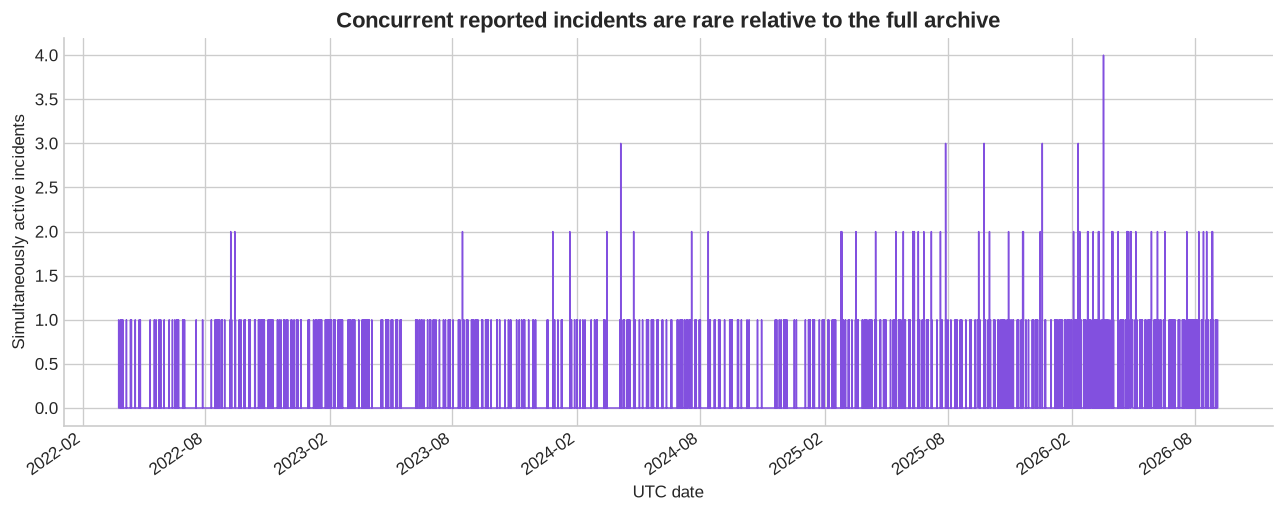

In [32]:
events = pd.DataFrame(
    [(s, 1) for s in incidents.start] + [(e, -1) for e in incidents.end],
    columns=["time", "delta"]
).groupby("time", as_index=False)["delta"].sum().sort_values("time")

segments = []
concurrency = 0
prev = None
for row in events.itertuples(index=False):
    if prev is not None and row.time > prev:
        segments.append((prev, row.time, concurrency))
    concurrency += row.delta
    prev = row.time
segments = pd.DataFrame(segments, columns=["start", "end", "concurrency"])
segments["hours"] = (segments.end - segments.start).dt.total_seconds() / 3600
event_state = events["delta"].cumsum()
max_concurrency = int(segments.concurrency.max())
max_event_state = int(event_state.max())
max_windows = merge_intervals(segments.loc[segments.concurrency.eq(max_concurrency), ["start", "end"]].itertuples(index=False, name=None))

hours_2plus = segments.loc[segments.concurrency.ge(2), "hours"].sum()
hours_3plus = segments.loc[segments.concurrency.ge(3), "hours"].sum()
hours_at_max = segments.loc[segments.concurrency.eq(max_concurrency), "hours"].sum()

concurrency_summary = pd.DataFrame({
    "hours": [hours_2plus, hours_3plus, hours_at_max],
    "share_of_observation": [hours_2plus / observed_hours, hours_3plus / observed_hours, hours_at_max / observed_hours],
}, index=["2+ simultaneous incidents", "3+ simultaneous incidents", f"At maximum concurrency ({max_concurrency})"])
display(concurrency_summary.style.format({"hours": "{:.2f}", "share_of_observation": "{:.4%}"}))
display(pd.DataFrame(max_windows, columns=["start", "end"]))

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.step(segments.start, segments.concurrency, where="post", color=COLORS["purple"], lw=.9)
ax.set(title="Concurrent reported incidents are rare relative to the full archive", xlabel="UTC date", ylabel="Simultaneously active incidents")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.show()

In [33]:
max_window_text = ", ".join(f"{s:%Y-%m-%d %H:%M}–{e:%Y-%m-%d %H:%M} UTC" for s, e in max_windows[:4])
display(Markdown(
    f"**Interpretation.** Maximum concurrency is **{max_concurrency} incidents**. At least two incidents overlap for "
    f"**{hours_2plus:,.2f} hours ({hours_2plus / observed_hours:.4%} of observed time)**; at least three for "
    f"**{hours_3plus:,.2f} hours ({hours_3plus / observed_hours:.4%})**; and maximum concurrency lasts "
    f"**{hours_at_max:,.2f} hours ({hours_at_max / observed_hours:.5%})**. Maximum-concurrency window(s): {max_window_text}."
))

**Interpretation.** Maximum concurrency is **4 incidents**. At least two incidents overlap for **80.07 hours (0.2053% of observed time)**; at least three for **6.72 hours (0.0172%)**; and maximum concurrency lasts **0.65 hours (0.00167%)**. Maximum-concurrency window(s): 2026-03-19 01:05–2026-03-19 01:44 UTC.

## 15. Does starting outside a US daytime window predict longer resolution?

The main comparison defines a **US daytime window as 13:00–21:00 UTC** and applies it to every day. It is not called “business hours” because the all-days version includes weekends. A robustness check repeats the comparison on Monday–Friday only.

Both comparisons are associative: they ignore US time zones, daylight saving, staffing, product mix, and severity.

All days


,n,median,p90
us_daytime_start,,,
Outside US daytime window,349,1.18,5.54
US daytime window (13:00–21:00 UTC),440,1.33,4.79


Mann–Whitney U p-value: 0.31
Monday–Friday only


,n,median,p90
us_daytime_start,,,
Outside US daytime window,318,1.20,5.52
US daytime window (13:00–21:00 UTC),425,1.32,4.78


Mann–Whitney U p-value: 0.482


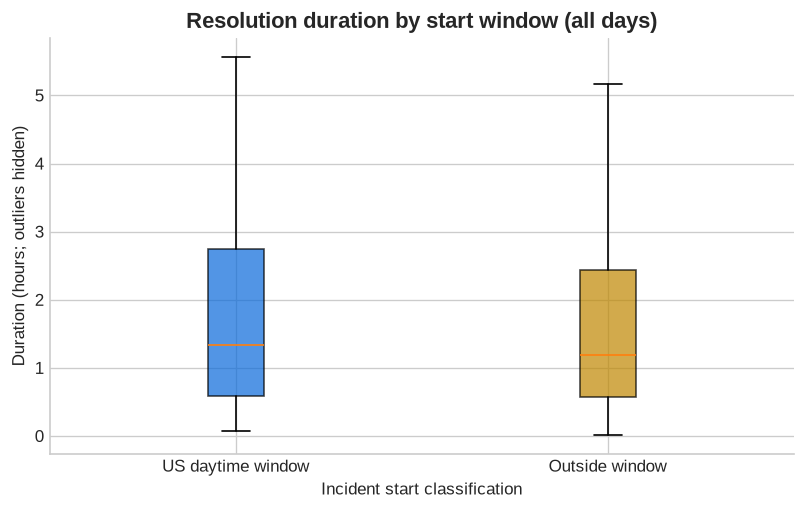

In [34]:
incidents["us_daytime_start"] = incidents["hour"].between(13, 20)
incidents["is_monday_friday"] = incidents["start"].dt.weekday.lt(5)

def window_comparison(frame):
    table = frame.groupby("us_daytime_start")["duration_hours"].agg(
        n="size", median="median", p90=lambda s: s.quantile(.90)
    ).rename(index={False: "Outside US daytime window", True: "US daytime window (13:00–21:00 UTC)"})
    daytime = frame.loc[frame.us_daytime_start, "duration_hours"]
    outside = frame.loc[~frame.us_daytime_start, "duration_hours"]
    pvalue = np.nan
    if mannwhitneyu is not None:
        _, pvalue = mannwhitneyu(daytime, outside, alternative="two-sided")
    return table, pvalue

all_days_window, all_days_pvalue = window_comparison(incidents)
weekday_window, weekday_pvalue = window_comparison(incidents[incidents.is_monday_friday])

print("All days")
display(all_days_window.style.format({"median": "{:.2f}", "p90": "{:.2f}"}))
print(f"Mann–Whitney U p-value: {all_days_pvalue:.3g}" if pd.notna(all_days_pvalue) else "SciPy unavailable; test omitted.")
print("Monday–Friday only")
display(weekday_window.style.format({"median": "{:.2f}", "p90": "{:.2f}"}))
print(f"Mann–Whitney U p-value: {weekday_pvalue:.3g}" if pd.notna(weekday_pvalue) else "SciPy unavailable; test omitted.")

fig, ax = plt.subplots(figsize=(8, 4.5))
daytime = incidents.loc[incidents.us_daytime_start, "duration_hours"]
outside = incidents.loc[~incidents.us_daytime_start, "duration_hours"]
bp = ax.boxplot([daytime, outside], tick_labels=["US daytime window", "Outside window"], showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], [COLORS["blue"], COLORS["orange"]]):
    patch.set_facecolor(color); patch.set_alpha(.7)
ax.set(title="Resolution duration by start window (all days)", xlabel="Incident start classification", ylabel="Duration (hours; outliers hidden)")
plt.show()

In [35]:
all_days_ratio = (all_days_window.loc["Outside US daytime window", "median"] /
                  all_days_window.loc["US daytime window (13:00–21:00 UTC)", "median"] - 1)
weekday_ratio = (weekday_window.loc["Outside US daytime window", "median"] /
                 weekday_window.loc["US daytime window (13:00–21:00 UTC)", "median"] - 1)
all_p_text = f"p={all_days_pvalue:.3g}" if pd.notna(all_days_pvalue) else "test unavailable"
weekday_p_text = f"p={weekday_pvalue:.3g}" if pd.notna(weekday_pvalue) else "test unavailable"

display(Markdown(
    f"**Interpretation.** Across all days, the US daytime-window median is "
    f"**{all_days_window.loc['US daytime window (13:00–21:00 UTC)', 'median']:.2f}h** "
    f"(n={int(all_days_window.loc['US daytime window (13:00–21:00 UTC)', 'n'])}) versus "
    f"**{all_days_window.loc['Outside US daytime window', 'median']:.2f}h** "
    f"(n={int(all_days_window.loc['Outside US daytime window', 'n'])}; {all_p_text}). "
    f"On Monday–Friday only, the corresponding medians are "
    f"**{weekday_window.loc['US daytime window (13:00–21:00 UTC)', 'median']:.2f}h** and "
    f"**{weekday_window.loc['Outside US daytime window', 'median']:.2f}h** ({weekday_p_text}). "
    "A non-significant p-value would indicate limited evidence of a distributional difference here—not proof that the groups are identical."
))

**Interpretation.** Across all days, the US daytime-window median is **1.33h** (n=440) versus **1.18h** (n=349; p=0.31). On Monday–Friday only, the corresponding medians are **1.32h** and **1.20h** (p=0.482). A non-significant p-value would indicate limited evidence of a distributional difference here—not proof that the groups are identical.

## 16. Did incident titles become more generic?

Exact-title frequency reveals both recurrent service problems and changes in reporting style. “Generic” below is a transparent rule: a title matching broad phrases such as “some GitHub services” or a generic “investigating reports” formulation.

,incidents
title,
Disruption with some GitHub services,112
Incident with Actions,73
Incident with Codespaces,71
Incident with Copilot,38
Incident with Pull Requests,27
We are investigating reports of degraded performance.,25
Incident with Webhooks,18
Incident with Git Operations,16
Incident with Issues,11


,sum,count,mean
2022 partial,3,101,3.0%
2023,17,164,10.4%
2024,30,120,25.0%
2025,60,188,31.9%
2026 YTD,40,216,18.5%


,total_occurrences,first_occurrence
Disruption with some GitHub services,112,2024-07-16 00:53:00+00:00
We are investigating reports of degraded performance.,25,2023-08-11 20:44:00+00:00


,title,year_label,count,share_of_year_incidents
0,Disruption with some GitHub services,2022 partial,0,0.0%
1,Disruption with some GitHub services,2023,0,0.0%
2,Disruption with some GitHub services,2024,16,13.3%
3,Disruption with some GitHub services,2025,59,31.4%
4,Disruption with some GitHub services,2026 YTD,37,17.1%
5,We are investigating reports of degraded performance.,2022 partial,0,0.0%
6,We are investigating reports of degraded performance.,2023,11,6.7%
7,We are investigating reports of degraded performance.,2024,14,11.7%
8,We are investigating reports of degraded performance.,2025,0,0.0%
9,We are investigating reports of degraded performance.,2026 YTD,0,0.0%


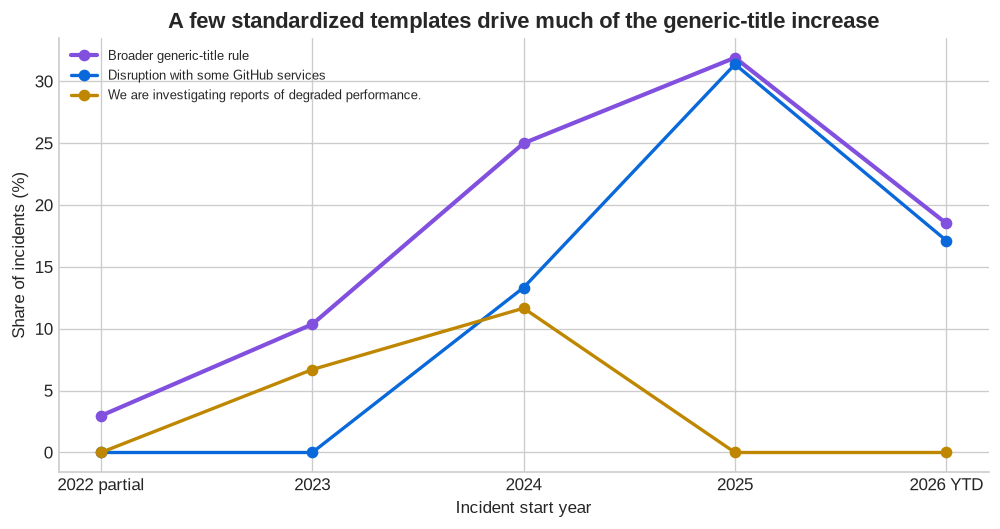

In [36]:
top_titles = incidents["title"].value_counts().head(15).rename("incidents").to_frame()
display(top_titles)

generic_pattern = r"(?i)(?:some github services|investigating reports of degraded performance|^incident on \d{4}-\d{2}-\d{2}$)"
incidents["generic_title"] = incidents["title"].str.contains(generic_pattern, regex=True, na=False)
generic_year_raw = incidents.groupby("year")["generic_title"].agg(["sum", "count", "mean"])
generic_year = generic_year_raw.copy()
generic_year.index = [label_year(y) for y in generic_year.index]

exact_titles = [
    "Disruption with some GitHub services",
    "We are investigating reports of degraded performance.",
]
exact_title_rows = []
for title in exact_titles:
    mask = incidents["title"].eq(title)
    for year in annual_totals.index:
        year_mask = incidents["year"].eq(year)
        count = int((mask & year_mask).sum())
        exact_title_rows.append({
            "title": title, "year": year, "year_label": label_year(year), "count": count,
            "share_of_year_incidents": count / int(year_mask.sum()),
        })
exact_title_yearly = pd.DataFrame(exact_title_rows)
exact_title_summary = pd.DataFrame({
    "total_occurrences": [incidents.title.eq(t).sum() for t in exact_titles],
    "first_occurrence": [incidents.loc[incidents.title.eq(t), "start"].min() for t in exact_titles],
}, index=exact_titles)

display(generic_year.style.format({"mean": "{:.1%}"}))
display(exact_title_summary)
display(exact_title_yearly[["title", "year_label", "count", "share_of_year_incidents"]]
        .style.format({"share_of_year_incidents": "{:.1%}"}))

standardized_mask = incidents.title.isin(exact_titles)
standardized_share_of_generic = standardized_mask.sum() / incidents.generic_title.sum()
latest_year = incidents.year.max()
latest_standardized_share_of_generic = (
    (standardized_mask & incidents.year.eq(latest_year)).sum() /
    (incidents.generic_title & incidents.year.eq(latest_year)).sum()
)

exact_share_pivot = exact_title_yearly.pivot(index="year_label", columns="title", values="share_of_year_incidents")
exact_share_pivot = exact_share_pivot.reindex(generic_year.index)
fig, ax = plt.subplots(figsize=(10, 4.7))
ax.plot(generic_year.index, generic_year["mean"] * 100, marker="o", lw=2.5, color=COLORS["purple"], label="Broader generic-title rule")
for title, color in zip(exact_titles, [COLORS["blue"], COLORS["orange"]]):
    ax.plot(exact_share_pivot.index, exact_share_pivot[title] * 100, marker="o", lw=2, label=title, color=color)
ax.set(title="A few standardized templates drive much of the generic-title increase", xlabel="Incident start year", ylabel="Share of incidents (%)")
ax.legend(fontsize=8)
plt.show()

In [37]:
generic_first = incidents.loc[incidents.generic_title, "start"].min()
most_common_title = top_titles.index[0]
primary_exact = exact_titles[0]
secondary_exact = exact_titles[1]
display(Markdown(
    f"**Interpretation.** The broader rule-based generic category first appears on **{generic_first:%Y-%m-%d}** and rises from "
    f"**{generic_year.iloc[0]['mean']:.1%}** in {generic_year.index[0]} to **{generic_year.iloc[-1]['mean']:.1%}** in {generic_year.index[-1]}. "
    f"Separately, the exact title **“{primary_exact}”** occurs **{exact_title_summary.loc[primary_exact, 'total_occurrences']} times**, first on "
    f"**{exact_title_summary.loc[primary_exact, 'first_occurrence']:%Y-%m-%d}**. **“{secondary_exact}”** occurs "
    f"**{exact_title_summary.loc[secondary_exact, 'total_occurrences']} times**, first on "
    f"**{exact_title_summary.loc[secondary_exact, 'first_occurrence']:%Y-%m-%d}**. Together these two templates account for "
    f"**{standardized_share_of_generic:.1%} of all rule-based generic titles** and **{latest_standardized_share_of_generic:.1%} in {label_year(latest_year)}**. "
    "This supports a reporting-vocabulary explanation and keeps the exact-title evidence distinct from the broader classifier."
))

**Interpretation.** The broader rule-based generic category first appears on **2022-09-13** and rises from **3.0%** in 2022 partial to **18.5%** in 2026 YTD. Separately, the exact title **“Disruption with some GitHub services”** occurs **112 times**, first on **2024-07-16**. **“We are investigating reports of degraded performance.”** occurs **25 times**, first on **2023-08-11**. Together these two templates account for **91.3% of all rule-based generic titles** and **92.5% in 2026 YTD**. This supports a reporting-vocabulary explanation and keeps the exact-title evidence distinct from the broader classifier.

## 17. What are the dataset's extreme events?

Extremes use exact merged exposure where relevant. A week is Monday–Sunday UTC; the longest affected-day run requires positive unique active time on every consecutive UTC date.

In [38]:
weekly_active = daily["active_hours"].resample("W-MON", label="left", closed="left").sum()
worst_week_exposure = weekly_active.idxmax()
longest_quiet_idx = all_gaps.idxmax()
shortest_gap_idx = all_gaps.idxmin()

extremes = pd.DataFrame([
    ["Longest incident", incidents.loc[incidents.duration_hours.idxmax(), "start"], fmt_hours(incidents.duration_hours.max()), incidents.loc[incidents.duration_hours.idxmax(), "title"]],
    ["Worst day by unique active time", daily.active_hours.idxmax(), fmt_hours(daily.active_hours.max()), "overlap-deduplicated"],
    ["Day with most incident starts", day_most_starts, f"{int(daily.incident_starts.max())} starts", "UTC day"],
    ["Worst week by unique active time", worst_week_exposure, fmt_hours(weekly_active.max()), "Monday-based UTC week"],
    ["Week with most incident starts", week_most_starts, f"{int(weekly_starts.max())} starts", "Monday-based UTC week"],
    ["Longest run of affected days", run_start, f"{run_days} days", f"through {run_end:%Y-%m-%d}"],
    ["Maximum concurrent incidents", max_windows[0][0], f"{max_concurrency} incidents", max_window_text],
    ["Longest gap between starts", incidents.loc[longest_quiet_idx, "start"], fmt_hours(all_gaps.max()), "gap ending at timestamp shown"],
    ["Shortest gap between starts", incidents.loc[shortest_gap_idx, "start"], f"{all_gaps.min() * 60:.1f} minutes", "gap ending at timestamp shown"],
], columns=["extreme", "date_or_start", "value", "detail"])
display(extremes)

,extreme,date_or_start,value,detail
0,Longest incident,2026-04-28 14:17:00+00:00,2.6 days,Incomplete pull request results in repositories
1,Worst day by unique active time,2025-04-16 00:00:00+00:00,1.0 days,overlap-deduplicated
2,Day with most incident starts,2026-02-09 00:00:00+00:00,7 starts,UTC day
3,Worst week by unique active time,2026-04-27 00:00:00+00:00,2.9 days,Monday-based UTC week
4,Week with most incident starts,2026-02-09 00:00:00+00:00,15 starts,Monday-based UTC week
5,Longest run of affected days,2026-07-19 00:00:00+00:00,7 days,through 2026-07-25
6,Maximum concurrent incidents,2026-03-19 01:05:00+00:00,4 incidents,2026-03-19 01:05–2026-03-19 01:44 UTC
7,Longest gap between starts,2023-06-07 16:45:00+00:00,21.4 days,gap ending at timestamp shown
8,Shortest gap between starts,2023-08-15 17:24:00+00:00,0.0 minutes,gap ending at timestamp shown


In [39]:
display(Markdown(
    f"**Interpretation.** The largest single window lasts **{fmt_hours(incidents.duration_hours.max())}**, while the worst day contains "
    f"**{daily.active_hours.max():.2f} unique active hours**. The longest continuous calendar run is **{run_days} affected days**. "
    "These maxima describe different failure modes: a single long tail, dense starts, persistent daily exposure, and concurrency."
))

**Interpretation.** The largest single window lasts **2.6 days**, while the worst day contains **24.00 unique active hours**. The longest continuous calendar run is **7 affected days**. These maxima describe different failure modes: a single long tail, dense starts, persistent daily exposure, and concurrency.

## 18. What additional pattern survives a simple robustness check?

Weekday/weekend comparisons combine frequency and duration. Start rates are normalized by the number of observed UTC days of each type; duration uses median and p90. This is descriptive and does not map neatly to local working calendars.

,incidents,median_hours,p90_hours,starts_per_observed_day
day_type,,,,
Weekday,743,1.27,5.12,0.639
Weekend,46,0.93,6.22,0.099


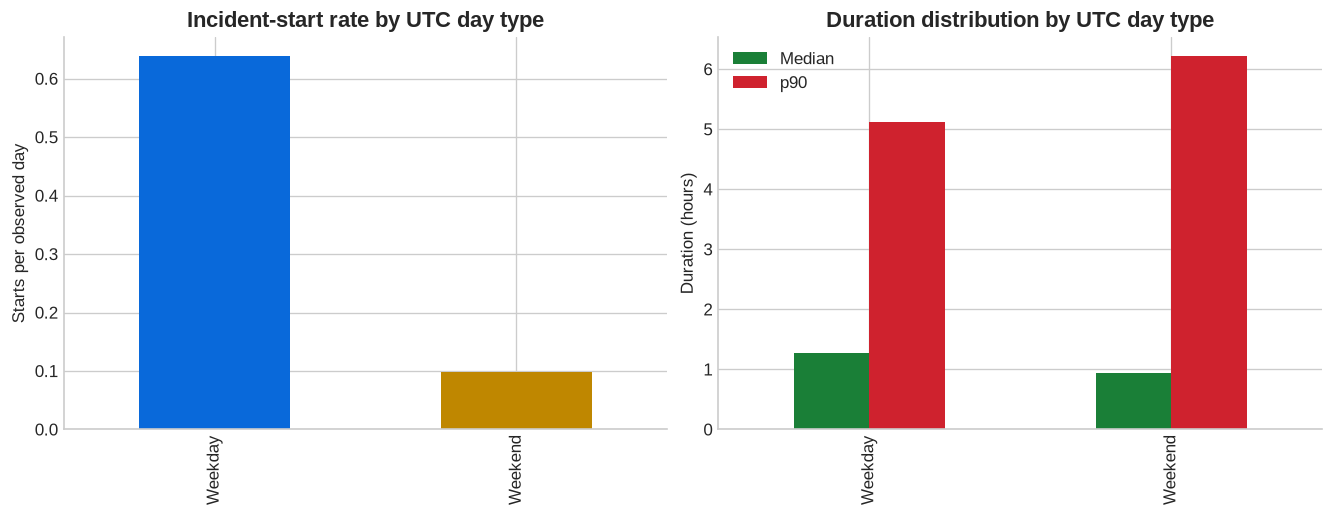

In [40]:
observed_days_by_type = pd.Series({
    "Weekday": daily.index.to_series().dt.weekday.lt(5).sum(),
    "Weekend": daily.index.to_series().dt.weekday.ge(5).sum(),
})
incidents["day_type"] = np.where(incidents.start.dt.weekday.lt(5), "Weekday", "Weekend")
weekpart = incidents.groupby("day_type")["duration_hours"].agg(
    incidents="size", median_hours="median", p90_hours=lambda s: s.quantile(.9)
)
weekpart["starts_per_observed_day"] = weekpart["incidents"] / observed_days_by_type
display(weekpart.style.format({"median_hours": "{:.2f}", "p90_hours": "{:.2f}", "starts_per_observed_day": "{:.3f}"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
weekpart["starts_per_observed_day"].plot.bar(ax=axes[0], color=[COLORS["blue"], COLORS["orange"]])
axes[0].set(title="Incident-start rate by UTC day type", xlabel="", ylabel="Starts per observed day")
weekpart[["median_hours", "p90_hours"]].plot.bar(ax=axes[1], color=[COLORS["green"], COLORS["red"]])
axes[1].set(title="Duration distribution by UTC day type", xlabel="", ylabel="Duration (hours)")
axes[1].legend(["Median", "p90"])
plt.show()

In [41]:
rate_ratio = weekpart.loc["Weekend", "starts_per_observed_day"] / weekpart.loc["Weekday", "starts_per_observed_day"]
duration_ratio = weekpart.loc["Weekend", "median_hours"] / weekpart.loc["Weekday", "median_hours"]
display(Markdown(
    f"**Interpretation.** Weekend UTC days have **{rate_ratio:.0%}** of the weekday incident-start rate "
    f"({weekpart.loc['Weekend', 'starts_per_observed_day']:.3f} vs {weekpart.loc['Weekday', 'starts_per_observed_day']:.3f} starts/day), "
    f"while their median duration is **{duration_ratio:.0%}** of the weekday median. "
    "This is a useful descriptive contrast, but product usage, deployment schedules, and reporting behavior are plausible confounders."
))

**Interpretation.** Weekend UTC days have **16%** of the weekday incident-start rate (0.099 vs 0.639 starts/day), while their median duration is **74%** of the weekday median. This is a useful descriptive contrast, but product usage, deployment schedules, and reporting behavior are plausible confounders.

## 19. Do the interval calculations reconcile?

Automated sanity checks guard the article-facing results against double-counting, impossible daily exposure, negative concurrency, and allocation drift.

In [42]:
tolerance_hours = 1e-6
component_row_share = component_mix.sum(axis=1)
multi_component_incidents = svc["components"].str.len().gt(1).sum()

checks = {
    "Merged active hours do not exceed summed duration": unique_hours <= naive_hours + tolerance_hours,
    "Every analyzed interval has end > start": bool((incidents.end > incidents.start).all()),
    "Daily active hours remain in [0, 24]": bool(daily.active_hours.between(-tolerance_hours, 24 + tolerance_hours).all()),
    "Daily exposure percentages remain in [0, 1]": bool(daily.active_pct.between(-tolerance_hours, 1 + tolerance_hours).all()),
    "Hourly exposure percentages remain in [0, 1]": bool(hour_exposure.active_pct.between(-tolerance_hours, 1 + tolerance_hours).all()),
    "Concurrency is never negative": bool(segments.concurrency.ge(0).all() and event_state.ge(0).all()),
    "Annual counts sum to cleaned incidents": int(yearly.incidents.sum()) == len(incidents),
    "Sweep-line maximum agrees with event state": max_concurrency == max_event_state,
    "Daily allocation sums to merged active hours": np.isclose(daily.active_hours.sum(), unique_hours, atol=tolerance_hours),
    "Hourly allocation sums to merged active hours": np.isclose(hour_frame.active.sum(), unique_hours, atol=tolerance_hours),
    "Each individual component share is at most 100%": bool(component_mix.le(1 + tolerance_hours).all().all()),
    "Share sums above 100% are explained by multi-component incidents": bool((component_row_share.le(1 + tolerance_hours).all()) or multi_component_incidents > 0),
}

consistency_checks = pd.DataFrame({
    "check": list(checks), "passed": list(checks.values())
})
display(consistency_checks)
assert all(checks.values()), consistency_checks.loc[~consistency_checks.passed, "check"].tolist()
print(f"All {len(checks)} consistency checks passed.")

,check,passed
0,Merged active hours do not exceed summed duration,True
1,Every analyzed interval has end > start,True
2,"Daily active hours remain in [0, 24]",True
3,"Daily exposure percentages remain in [0, 1]",True
4,"Hourly exposure percentages remain in [0, 1]",True
5,Concurrency is never negative,True
6,Annual counts sum to cleaned incidents,True
7,Sweep-line maximum agrees with event state,True
8,Daily allocation sums to merged active hours,True
9,Hourly allocation sums to merged active hours,True


All 12 consistency checks passed.


In [43]:
display(Markdown(
    f"**Interpretation.** All **{len(checks)} checks pass**. Daily and hourly allocations both reconcile to "
    f"**{unique_hours:,.6f} merged active hours** within {tolerance_hours} hour, and the sweep line independently reproduces "
    f"the maximum concurrency of **{max_concurrency}**. Component shares are non-exclusive because **{multi_component_incidents} incidents** mention multiple components."
))

**Interpretation.** All **12 checks pass**. Daily and hourly allocations both reconcile to **1,816.650000 merged active hours** within 1e-06 hour, and the sweep line independently reproduces the maximum concurrency of **4**. Component shares are non-exclusive because **166 incidents** mention multiple components.

## Key findings

The ranked list below is generated from the live data so its numbers stay aligned with the charts. Statements are labeled as **measured fact**, **interpretation**, or **hypothesis**.

In [44]:
findings = [
    f"1. **Measured fact — overlap-adjusted exposure.** At least one reported incident was active for **{corrected_active_pct:.3%} of observed time** ({fmt_hours(unique_hours)}). Naively summing windows overstates that by **{overlap_hours / naive_hours:.1%}**.",
    f"2. **Measured fact — frequency.** The normalized start rate moved from **{yearly.iloc[0].incidents_per_month:.1f} incidents/month in {yearly.iloc[0].label}** to **{yearly.iloc[-1].incidents_per_month:.1f} in {yearly.iloc[-1].label}**; the median start gap moved from **{yearly.iloc[0].median_start_gap_hours:.1f}h** to **{yearly.iloc[-1].median_start_gap_hours:.1f}h**.",
    f"3. **Measured fact — duration is long-tailed.** Median duration is **{q.loc[.5]:.2f}h**, mean duration is **{incidents.duration_hours.mean():.2f}h**, and p95 is **{q.loc[.95]:.2f}h**. The longest 1% supply **{tail_share:.1%}** of summed incident-hours.",
    f"4. **Measured fact — typical versus tail.** From {yearly.iloc[0].label} to {yearly.iloc[-1].label}, the median changed **{med_change:+.0%}** and p95 changed **{p95_change:+.0%}**. **Interpretation:** annual tails are volatile, so averages alone are poor trend measures.",
    f"5. **Measured fact — exposure timing.** {highest_exposure_weekday} has the highest weekday exposure (**{weekday_exposure.loc[highest_exposure_weekday, 'active_pct']:.3%}**); exposure peaks at **{peak_exposure_hour:02d}:00 UTC**, while starts peak at **{peak_start_hour:02d}:00 UTC**.",
    f"6. **Measured fact — components.** " + " ".join(service_sentence(s) for s in ["Actions", "Copilot", "Codespaces"]) + f" **{svc.component_attribution.eq('Unattributed').mean():.1%}** remain unattributed.",
    f"7. **Measured fact — clustering.** **{all_gaps.le(24).mean():.1%}** of consecutive incident starts occur within 24h; for same-component recurrences the share is **{cg.le(24).mean():.1%}**. **Interpretation:** this is temporal crowding, not proof of dependence.",
    f"8. **Measured fact — concurrency.** Maximum concurrency is **{max_concurrency}**, with **{hours_2plus:,.1f}h ({hours_2plus / observed_hours:.4%})** at 2+ simultaneous incidents and **{hours_3plus:,.1f}h ({hours_3plus / observed_hours:.4%})** at 3+.",
    f"9. **Measured fact — reporting vocabulary.** The exact title “{primary_exact}” occurs **{exact_title_summary.loc[primary_exact, 'total_occurrences']} times**; two standardized templates explain **{standardized_share_of_generic:.1%}** of the broader generic-title class.",
    f"10. **Interpretation — severity taxonomy.** **{critical.year.eq(2026).sum()} of {len(critical)}** critical labels occur in 2026 YTD, while critical durations are **{severity_stats.loc['critical', 'median_duration_hours']:.2f}h median / {severity_stats.loc['critical', 'p90_duration_hours']:.2f}h p90**. This is compatible with a classification change, not proof of one.",
    f"11. **Hypothesis, weak evidence — seasonality.** {quiet_month} has the lowest normalized start rate (**{month_rate.min():.1f}/month**) and {busy_month} the highest (**{month_rate.max():.1f}/month**), but fewer than five full cycles are insufficient for a strong seasonal claim.",
]
display(Markdown("\n\n".join(findings)))

1. **Measured fact — overlap-adjusted exposure.** At least one reported incident was active for **4.659% of observed time** (75.7 days). Naively summing windows overstates that by **4.6%**.

2. **Measured fact — frequency.** The normalized start rate moved from **10.9 incidents/month in 2022 partial** to **26.6 in 2026 YTD**; the median start gap moved from **37.3h** to **17.1h**.

3. **Measured fact — duration is long-tailed.** Median duration is **1.27h**, mean duration is **2.41h**, and p95 is **7.74h**. The longest 1% supply **15.4%** of summed incident-hours.

4. **Measured fact — typical versus tail.** From 2022 partial to 2026 YTD, the median changed **+20%** and p95 changed **+68%**. **Interpretation:** annual tails are volatile, so averages alone are poor trend measures.

5. **Measured fact — exposure timing.** Wednesday has the highest weekday exposure (**8.077%**); exposure peaks at **16:00 UTC**, while starts peak at **14:00 UTC**.

6. **Measured fact — components.** Actions remained common while declining: 30.7% in 2022 partial → 25.5% in 2026 YTD (-5.2% points). Copilot rose: 4.0% in 2022 partial → 25.0% in 2026 YTD (+21.0% points). Codespaces fell: 28.7% in 2022 partial → 5.6% in 2026 YTD (-23.2% points). **18.0%** remain unattributed.

7. **Measured fact — clustering.** **49.1%** of consecutive incident starts occur within 24h; for same-component recurrences the share is **13.7%**. **Interpretation:** this is temporal crowding, not proof of dependence.

8. **Measured fact — concurrency.** Maximum concurrency is **4**, with **80.1h (0.2053%)** at 2+ simultaneous incidents and **6.7h (0.0172%)** at 3+.

9. **Measured fact — reporting vocabulary.** The exact title “Disruption with some GitHub services” occurs **112 times**; two standardized templates explain **91.3%** of the broader generic-title class.

10. **Interpretation — severity taxonomy.** **26 of 27** critical labels occur in 2026 YTD, while critical durations are **2.02h median / 8.21h p90**. This is compatible with a classification change, not proof of one.

11. **Hypothesis, weak evidence — seasonality.** Dec has the lowest normalized start rate (**10.5/month**) and Feb the highest (**19.5/month**), but fewer than five full cycles are insufficient for a strong seasonal claim.

## Article-ready findings

This fact table is generated entirely from the current analysis variables. `high` confidence denotes direct timestamp arithmetic or exact counts; `moderate` marks comparisons exposed to reporting-scope or partial-period effects; `weak` marks limited seasonal evidence.

In [45]:
article_ready = pd.DataFrame([
    ["Cleaned unplanned incidents", f"{len(incidents):,}", f"from {observation_start:%Y-%m-%d} archive coverage through {observation_end:%Y-%m-%d}", "high", "Maintenance, duplicates, and invalid/non-positive windows excluded."],
    ["Overlap-adjusted incident exposure", f"{unique_hours:,.2f} hours ({corrected_active_pct:.3%})", f"naive sum {naive_hours:,.2f} hours; overlap removed {overlap_hours:,.2f} hours", "high", "Exact merged half-open UTC intervals."],
    ["Annual exposure", f"{yearly.iloc[-1].active_pct:.3%} in {yearly.iloc[-1].label}", f"{yearly.iloc[0].active_pct:.3%} in {yearly.iloc[0].label}", "moderate", "Both endpoints use exact partial-period denominators; reporting scope may differ."],
    ["Incident-start rate", f"{yearly.iloc[-1].incidents_per_month:.1f} per observed month", f"{yearly.iloc[0].incidents_per_month:.1f} in {yearly.iloc[0].label}", "moderate", "Normalized for partial calendar-month coverage."],
    ["Median gap between starts", f"{yearly.iloc[-1].median_start_gap_hours:.1f} hours in {yearly.iloc[-1].label}", f"{yearly.iloc[0].median_start_gap_hours:.1f} hours in {yearly.iloc[0].label}", "moderate", "Describes frequency, not causal clustering."],
    ["Incident duration", f"median {q.loc[.5]:.2f} hours; p95 {q.loc[.95]:.2f} hours", f"mean {incidents.duration_hours.mean():.2f} hours", "high", f"Longest 1% contribute {tail_share:.1%} of summed incident-hours."],
    ["Peak exposure time", f"{highest_exposure_weekday}; {peak_exposure_hour:02d}:00 UTC overall", f"weekday high/low ratio {weekday_exposure_ratio:.2f}×; starts peak {peak_start_hour:02d}:00 UTC", "high", "Exposure uses exact hourly allocation; starts are a separate measure."],
    ["Actions / Copilot / Codespaces mix", "; ".join(f"{k} {v:+.1f} pp" for k, v in component_change_pp.items()), f"{component_mix.index[0]} to {component_mix.index[-1]}", "moderate", f"Multi-label attribution; {svc.component_attribution.eq('Unattributed').mean():.1%} unattributed and {svc.component_attribution.eq('Model-inferred').mean():.1%} model-inferred."],
    ["Quietest calendar month", f"{quiet_month}: {month_rate.min():.1f} incidents per observed month", f"busiest {busy_month}: {month_rate.max():.1f}", "weak", "Fewer than five complete annual cycles; causal explanations are hypotheses."],
    ["Maximum concurrency", f"{max_concurrency} incidents for {hours_at_max:.2f} hours", f"2+ for {hours_2plus:.2f} hours ({hours_2plus / observed_hours:.4%}); 3+ for {hours_3plus:.2f} hours ({hours_3plus / observed_hours:.4%})", "high", "Exact event-based sweep line."],
    ["Longest incident", f"{incidents.duration_hours.max():.2f} hours", f"{incidents.loc[incidents.duration_hours.idxmax(), 'title']} starting {incidents.loc[incidents.duration_hours.idxmax(), 'start']:%Y-%m-%d}", "high", "Single published incident window."],
    ["Busiest day and longest affected streak", f"{day_most_starts:%Y-%m-%d}: {int(daily.loc[day_most_starts, 'incident_starts'])} starts", f"{run_days} consecutive affected days ({run_start:%Y-%m-%d} to {run_end:%Y-%m-%d})", "high", "UTC dates; affected means positive unique incident-active time."],
], columns=["finding", "value", "comparison", "confidence", "notes"])

mr.Markdown("**Copy note:** the table and plain-text block below are generated from the live dataset used in this run.")
display(article_ready)
print("ARTICLE-READY CURRENT NUMBERS")
print(f"Analysis timestamp: {downloaded_at:%Y-%m-%d %H:%M:%S UTC}")
print(article_ready.to_string(index=False))

MarkdownWidget(value='<div style="font-family: ui-sans-serif, system-ui, -apple-system, \'Segoe UI\', Roboto, …

,finding,value,comparison,confidence,notes
0,Cleaned unplanned incidents,789,from 2022-03-24 archive coverage through 2026-...,high,"Maintenance, duplicates, and invalid/non-posit..."
1,Overlap-adjusted incident exposure,"1,816.65 hours (4.659%)","naive sum 1,904.08 hours; overlap removed 87.4...",high,Exact merged half-open UTC intervals.
2,Annual exposure,9.812% in 2026 YTD,3.017% in 2022 partial,moderate,Both endpoints use exact partial-period denomi...
3,Incident-start rate,26.6 per observed month,10.9 in 2022 partial,moderate,Normalized for partial calendar-month coverage.
4,Median gap between starts,17.1 hours in 2026 YTD,37.3 hours in 2022 partial,moderate,"Describes frequency, not causal clustering."
5,Incident duration,median 1.27 hours; p95 7.74 hours,mean 2.41 hours,high,Longest 1% contribute 15.4% of summed incident...
6,Peak exposure time,Wednesday; 16:00 UTC overall,weekday high/low ratio 6.71×; starts peak 14:0...,high,Exposure uses exact hourly allocation; starts ...
7,Actions / Copilot / Codespaces mix,Actions -5.2 pp; Copilot +21.0 pp; Codespaces ...,2022 partial to 2026 YTD,moderate,Multi-label attribution; 18.0% unattributed an...
8,Quietest calendar month,Dec: 10.5 incidents per observed month,busiest Feb: 19.5,weak,Fewer than five complete annual cycles; causal...
9,Maximum concurrency,4 incidents for 0.65 hours,2+ for 80.07 hours (0.2053%); 3+ for 6.72 hour...,high,Exact event-based sweep line.


ARTICLE-READY CURRENT NUMBERS
Analysis timestamp: 2026-09-04 12:05:41 UTC
                                finding                                                  value                                                          comparison confidence                                                                             notes
            Cleaned unplanned incidents                                                    789                 from 2022-03-24 archive coverage through 2026-09-04       high               Maintenance, duplicates, and invalid/non-positive windows excluded.
     Overlap-adjusted incident exposure                                1,816.65 hours (4.659%)               naive sum 1,904.08 hours; overlap removed 87.43 hours       high                                             Exact merged half-open UTC intervals.
                        Annual exposure                                     9.812% in 2026 YTD                                              3.017% in 2022 par